## 🧠 Building Expected Passes (xP) for Women’s Football

**Competition Focus:** Top 5 European Football Leagues 2015/16
**Purpose:** Build an Expected Passes (xP) model to quantify pass difficulty and decision-making  
**Methods:** Feature engineering, probabilistic modelling, model evaluation  
**Author:** [Victoria Friss de Kereki](https://www.linkedin.com/in/victoria-friss-de-kereki/)  
**Medium Articles:**  _TBC_



**Notebook first written:** `03/04/2026`  
**Last updated:** `03/04/2026`  

> This notebook develops an Expected Passes (xP) model tailored to top European men's football. The objective is to evaluate passing decisions beyond completion rates by estimating the likelihood of a pass being successfully completed given its context. The approach is modular and can be reused for different datasets, competitions, or extended into possession-value frameworks.
frameworks.


## Packages and configuration

In [1]:
from statsbombpy import sb
import pandas as pd
import numpy as np
from mplsoccer import VerticalPitch,Pitch
from highlight_text import ax_text, fig_text
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
import pprint
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from tqdm import tqdm  # optional, shows progress bar
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings("ignore", message="credentials were not supplied")

## Load Competiton, Match, and Event Data from statsbombpy

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Call statsbomb API to get all free competitions, then check Women's comps
free_comps = sb.competitions()
men_comps = free_comps[free_comps['competition_gender'] == 'male']
men_comps

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
...,...,...,...,...,...,...,...,...,...,...,...,...
66,12,27,Italy,Serie A,male,False,False,2015/2016,2025-07-21T05:01:00.434081,None,None,2025-07-21T05:01:00.434081
67,12,86,Italy,Serie A,male,False,False,1986/1987,2023-06-18T01:55:53.343752,None,None,2023-06-18T01:55:53.343752
68,55,282,Europe,UEFA Euro,male,False,True,2024,2024-09-28T16:51:20.698794,2025-03-24T14:12:30.785094,2025-03-24T14:12:30.785094,2024-09-28T16:51:20.698794
69,55,43,Europe,UEFA Euro,male,False,True,2020,2024-07-31T12:29:15.702309,2024-07-31T12:30:57.587087,2024-07-31T12:30:57.587087,2024-07-31T12:29:15.702309


In [3]:
# Prepare list to store match counts
match_counts = []

# Loop over each competition_id + season_id
for comp_id, season_id in zip(men_comps['competition_id'], men_comps['season_id']):
    # Count actual matches
    try:
        matches = sb.matches(competition_id=comp_id, season_id=season_id)
        matches_count = len(matches)
    except:
        matches_count = 0

    match_counts.append({
        'competition_id': comp_id,
        'season_id': season_id,
        'matches_count': matches_count
    })

# Convert to DataFrame
match_counts_df = pd.DataFrame(match_counts)

# Join metadata from men_comps
metadata_cols = ['competition_id', 'season_id', 'competition_name', 'season_name',
                 'match_updated', 'match_updated_360', 'match_available_360', 'match_available']
match_counts_df = match_counts_df.merge(men_comps[metadata_cols], on=['competition_id', 'season_id'], how='left')

# Sort by actual matches
match_counts_df.sort_values('matches_count', ascending=False, inplace=True)
match_counts_df.reset_index(drop=True, inplace=True)

In [4]:
match_counts_df[['competition_id', 'competition_name', 'season_id', 'season_name',
                 'matches_count', 'match_updated', 'match_updated_360',
                 'match_available_360', 'match_available']].head(10)

,competition_id,competition_name,season_id,season_name,matches_count,match_updated,match_updated_360,match_available_360,match_available
0,12,Serie A,27,2015/2016,380,2025-07-21T05:01:00.434081,None,None,2025-07-21T05:01:00.434081
1,2,Premier League,27,2015/2016,380,2025-04-23T14:36:29.347042,2021-06-13T16:17:31.694,None,2025-04-23T14:36:29.347042
2,11,La Liga,27,2015/2016,380,2025-04-23T13:59:22.835792,2021-06-13T16:17:31.694,None,2025-04-23T13:59:22.835792
3,7,Ligue 1,27,2015/2016,377,2024-12-16T08:48:23.066123,None,None,2024-12-16T08:48:23.066123
4,9,1. Bundesliga,27,2015/2016,306,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
5,1238,Indian Super league,108,2021/2022,115,2024-09-29T17:46:01.175308,None,None,2024-09-29T17:46:01.175308
6,43,FIFA World Cup,3,2018,64,2024-06-12T07:38:19.345758,2021-06-13T16:17:31.694,None,2024-06-12T07:38:19.345758
7,43,FIFA World Cup,106,2022,64,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,2024-12-16T10:21:13.710934,2024-12-16T10:15:11.055845
8,1267,African Cup of Nations,107,2023,52,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
9,55,UEFA Euro,43,2020,51,2024-07-31T12:29:15.702309,2024-07-31T12:30:57.587087,2024-07-31T12:30:57.587087,2024-07-31T12:29:15.702309


## All matches in Top 5 2015/16

In [5]:
leagues = [
    (12, 27),  # Serie A
    (2, 27),   # Premier League
    (11, 27),  # La Liga
    (7, 27),   # Ligue 1
    (9, 27)    # Bundesliga
]

all_matches = []

for comp_id, season_id in leagues:
    matches = sb.matches(
        competition_id=comp_id,
        season_id=season_id
    )
    
    # recommended: keep league identifier for later analysis
    matches["competition_id"] = comp_id
    
    all_matches.append(matches)

matches_df = pd.concat(all_matches, ignore_index=True)

In [6]:
len(matches_df)

1823

## All events, then keep passes only

In [7]:
import pandas as pd
from statsbombpy import sb
from pathlib import Path
from tqdm import tqdm  # progress bar

# Cache folder
CACHE_DIR = Path("statsbomb_cache/events_15_16")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def load_events(match_id):
    """Load events for a match, using cache if available."""
    cache_file = CACHE_DIR / f"{match_id}.parquet"

    if cache_file.exists():
        return pd.read_parquet(cache_file)

    events = sb.events(match_id=match_id)
    events.to_parquet(cache_file)
    return events

In [8]:
from tqdm import tqdm

all_passes = []

for match_id in tqdm(matches_df["match_id"], desc="Extracting passes"):
    events = load_events(match_id)
    passes = events[events["type"] == "Pass"].copy()
    passes["match_id"] = match_id
    all_passes.append(passes)

passes_df = pd.concat(all_passes, ignore_index=True)

Extracting passes: 100%|██████████| 1823/1823 [00:54<00:00, 33.18it/s]


In [9]:
len(passes_df)

1777412

In [10]:
passes_clean = passes_df.dropna(axis=1, how="all")
passes_clean.head()

,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball
0,None,0.462911,819a652e-ec2e-408b-9c40-253c2be88817,5,"[61.0, 40.1]",3879863,0,None,None,None,2.425849,None,Right Foot,None,None,"[58.7, 42.1]",None,Ground Pass,3.047950,None,None,None,None,Luca Cigarini,8420.0,None,None,None,Kick Off,1,From Kick Off,Marten de Roon,6994.0,Left Defensive Midfield,2,Atalanta,228,[48c2d1ac-974b-49ae-ad53-d67d7d4964ed],0,Atalanta,228,00:00:00.556,Pass,None,NaN,NaN,NaN,NaN
1,None,1.485047,3f4a5604-9133-4782-92ce-3e09dcd39a1e,8,"[57.6, 42.1]",3879863,0,None,None,None,2.949424,None,Right Foot,None,None,"[35.5, 46.4]",None,Ground Pass,22.514440,None,None,None,None,Andrea Masiello,6992.0,None,None,None,None,1,From Kick Off,Luca Cigarini,8420.0,Right Defensive Midfield,2,Atalanta,228,[86364818-6ea7-48c7-9b6a-4c31e98c8a88],1,Atalanta,228,00:00:01.424,Pass,None,NaN,NaN,NaN,NaN
2,None,2.245250,8a442c77-0c85-4679-8249-6c76a7efca08,11,"[37.3, 46.2]",3879863,0,None,None,None,-0.722979,None,Right Foot,None,None,"[78.1, 10.2]",None,High Pass,54.411762,None,None,Incomplete,None,Jasmin Kurtič,6941.0,None,None,None,None,1,From Kick Off,Andrea Masiello,6992.0,Right Center Back,2,Atalanta,228,"[3ef041a3-3b8e-47d2-9e1d-a2d3d7e0cf31, 7769022...",3,Atalanta,228,00:00:03.925,Pass,None,NaN,NaN,NaN,NaN
3,None,2.842875,77690229-6f19-48d7-b712-27c6768792f1,13,"[42.0, 69.9]",3879863,0,None,None,None,-1.230292,None,Head,None,None,"[52.7, 39.7]",None,High Pass,32.039505,None,None,None,None,Emil Hallfreðsson,5512.0,None,None,None,Interception,1,From Kick Off,Silvan Widmer,7796.0,Right Wing Back,2,Atalanta,228,"[569e7e43-1151-4a02-8708-3e3b67c7a746, 8a442c7...",6,Udinese,230,00:00:06.170,Pass,None,NaN,NaN,NaN,NaN
4,None,1.385082,f703f951-6812-4bd1-ac4c-8fbe4717b137,15,"[53.3, 39.7]",3879863,0,None,None,None,-1.458369,None,Head,None,None,"[54.0, 33.5]",None,High Pass,6.239391,None,None,Incomplete,None,None,NaN,None,None,None,None,1,From Kick Off,Emil Hallfreðsson,5512.0,Left Center Midfield,2,Atalanta,228,[4f307b3e-43e6-4f88-bbd9-c93872eaf92b],9,Udinese,230,00:00:09.013,Pass,None,NaN,NaN,NaN,NaN


In [11]:
len(passes_clean)

1777412

In [12]:
passes_clean["play_pattern"].unique()

array(['From Kick Off', 'From Throw In', 'Regular Play', 'From Corner',
       'From Goal Kick', 'From Free Kick', 'From Keeper', 'Other',
       'From Counter'], dtype=object)

In [16]:
# Select only the columns we need from matches_df
league_info = matches_df[["match_id", "competition","match_date","match_week","home_team","away_team","home_score","away_score"]]

# Merge with passes
passes_clean = passes_clean.merge(
    league_info,
    on="match_id",
    how="left"
)

# Rename for clarity
passes_clean.head()

,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,competition_x,competition_y,match_date,match_week,home_team,away_team,home_score,away_score
0,None,0.462911,819a652e-ec2e-408b-9c40-253c2be88817,5,"[61.0, 40.1]",3879863,0,None,None,None,2.425849,None,Right Foot,None,None,"[58.7, 42.1]",None,Ground Pass,3.047950,None,None,None,None,Luca Cigarini,8420.0,None,None,None,Kick Off,1,From Kick Off,Marten de Roon,6994.0,Left Defensive Midfield,2,Atalanta,228,[48c2d1ac-974b-49ae-ad53-d67d7d4964ed],0,Atalanta,228,00:00:00.556,Pass,None,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1
1,None,1.485047,3f4a5604-9133-4782-92ce-3e09dcd39a1e,8,"[57.6, 42.1]",3879863,0,None,None,None,2.949424,None,Right Foot,None,None,"[35.5, 46.4]",None,Ground Pass,22.514440,None,None,None,None,Andrea Masiello,6992.0,None,None,None,None,1,From Kick Off,Luca Cigarini,8420.0,Right Defensive Midfield,2,Atalanta,228,[86364818-6ea7-48c7-9b6a-4c31e98c8a88],1,Atalanta,228,00:00:01.424,Pass,None,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1
2,None,2.245250,8a442c77-0c85-4679-8249-6c76a7efca08,11,"[37.3, 46.2]",3879863,0,None,None,None,-0.722979,None,Right Foot,None,None,"[78.1, 10.2]",None,High Pass,54.411762,None,None,Incomplete,None,Jasmin Kurtič,6941.0,None,None,None,None,1,From Kick Off,Andrea Masiello,6992.0,Right Center Back,2,Atalanta,228,"[3ef041a3-3b8e-47d2-9e1d-a2d3d7e0cf31, 7769022...",3,Atalanta,228,00:00:03.925,Pass,None,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1
3,None,2.842875,77690229-6f19-48d7-b712-27c6768792f1,13,"[42.0, 69.9]",3879863,0,None,None,None,-1.230292,None,Head,None,None,"[52.7, 39.7]",None,High Pass,32.039505,None,None,None,None,Emil Hallfreðsson,5512.0,None,None,None,Interception,1,From Kick Off,Silvan Widmer,7796.0,Right Wing Back,2,Atalanta,228,"[569e7e43-1151-4a02-8708-3e3b67c7a746, 8a442c7...",6,Udinese,230,00:00:06.170,Pass,None,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1
4,None,1.385082,f703f951-6812-4bd1-ac4c-8fbe4717b137,15,"[53.3, 39.7]",3879863,0,None,None,None,-1.458369,None,Head,None,None,"[54.0, 33.5]",None,High Pass,6.239391,None,None,Incomplete,None,None,NaN,None,None,None,None,1,From Kick Off,Emil Hallfreðsson,5512.0,Left Center Midfield,2,Atalanta,228,[4f307b3e-43e6-4f88-bbd9-c93872eaf92b],9,Udinese,230,00:00:09.013,Pass,None,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1


In [17]:
passes_clean.to_csv("Datasets/passes_mens_europe_15_16.csv", index=False)

In [2]:
passes_clean = pd.read_csv("Datasets/passes_mens_europe_15_16.csv")

## Data Inspection and Cleaning

In [3]:
# Filter rows where all columns are NaN
all_nan_rows = passes_clean[passes_clean.isna().all(axis=1)]

# Show all columns for these rows
pd.set_option("display.max_columns", None)
print(all_nan_rows)

# Optional: count how many there are
print(f"Number of rows where all values are NaN: {len(all_nan_rows)}")

Empty DataFrame
Columns: [counterpress, duration, id, index, location, match_id, minute, off_camera, out, pass_aerial_won, pass_angle, pass_assisted_shot_id, pass_body_part, pass_cross, pass_cut_back, pass_end_location, pass_goal_assist, pass_height, pass_length, pass_miscommunication, pass_no_touch, pass_outcome, pass_outswinging, pass_recipient, pass_recipient_id, pass_shot_assist, pass_switch, pass_technique, pass_type, period, play_pattern, player, player_id, position, possession, possession_team, possession_team_id, related_events, second, team, team_id, timestamp, type, under_pressure, pass_deflected, pass_inswinging, pass_straight, pass_through_ball, competition_x, competition_y, match_date, match_week, home_team, away_team, home_score, away_score]
Index: []
Number of rows where all values are NaN: 0


In [4]:
def extract_coords(coord_col):
    # Convert everything to string first, then split
    x = pd.to_numeric(coord_col.astype(str).str.strip("[]").str.split().str[0], errors="coerce")
    y = pd.to_numeric(coord_col.astype(str).str.strip("[]").str.split().str[1], errors="coerce")
    return x, y

# Apply to location columns
passes_clean["start_x"], passes_clean["start_y"] = extract_coords(passes_clean["location"])
passes_clean["end_x"], passes_clean["end_y"] = extract_coords(passes_clean["pass_end_location"])

# Check missing values
cols = ["start_x", "start_y", "end_x", "end_y"]
print(passes_clean[cols].isna().sum())

start_x    0
start_y    0
end_x      0
end_y      0
dtype: int64


In [5]:
len(passes_clean)

1777412

In [6]:
pd.crosstab(
    passes_clean["pass_type"], 
    passes_clean["play_pattern"], 
    dropna=False
)

play_pattern,From Corner,From Counter,From Free Kick,From Goal Kick,From Keeper,From Kick Off,From Throw In,Other,Regular Play
pass_type,,,,,,,,,
Corner,18391,0,0,0,0,0,0,0,0
Free Kick,0,0,54541,0,0,0,0,0,0
Goal Kick,0,0,0,30077,0,0,0,0,0
Interception,205,344,1389,1023,250,236,3071,9,8914
Kick Off,0,0,0,0,24,8409,0,0,0
Recovery,6985,2790,22631,19358,3979,3747,33697,516,90227
Throw-in,0,0,0,0,0,0,84783,0,0
NaN,33552,9315,200578,90101,46078,46420,314476,2286,639010


In [7]:
passes_clean["pass_outcome"].value_counts(dropna=False)

pass_outcome
NaN                 1360985
Incomplete           358811
Out                   34957
Unknown               12074
Pass Offside           7640
Injury Clearance       2945
Name: count, dtype: int64

In [8]:
# 1️⃣ Replace NaN with "Complete"
passes_clean["pass_outcome"] = passes_clean["pass_outcome"].fillna("Complete")

# 2️⃣ Quick check after replacement
passes_clean["pass_outcome"].value_counts()

pass_outcome
Complete            1360985
Incomplete           358811
Out                   34957
Unknown               12074
Pass Offside           7640
Injury Clearance       2945
Name: count, dtype: int64

In [9]:
# Percentage of Unknown passes
total_passes = len(passes_clean)
unknown_passes = passes_clean[passes_clean["pass_outcome"] == "Unknown"]
percent_unknown = len(unknown_passes) / total_passes * 100

print(f"Unknown passes: {len(unknown_passes)} / {total_passes} ({percent_unknown:.2f}%)")

# Show all columns for inspection
with pd.option_context("display.max_columns", None):
    display(unknown_passes.head())

Unknown passes: 12074 / 1777412 (0.68%)


,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,competition_x,competition_y,match_date,match_week,home_team,away_team,home_score,away_score,start_x,start_y,end_x,end_y
599,NaN,1.381080,06e46eec-90dc-458f-9d2f-2cb4f8dbec17,2061,[53.7 0.1],3879863,51,NaN,NaN,NaN,0.165149,NaN,NaN,NaN,NaN,[68.1 2.5],NaN,High Pass,14.598630,NaN,NaN,Unknown,NaN,Marco Borriello,8871.0,NaN,NaN,NaN,Throw-in,2,From Throw In,Davide Brivio,31231.0,Left Back,98,Atalanta,228,['0248d832-a0da-43a6-b3f7-e7265c1a9a39'],52,Atalanta,228,00:06:52.325,Pass,NaN,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1,53.7,0.1,68.1,2.5
717,NaN,1.067991,02c82329-b725-488e-b109-b5b5d1b5ef47,2454,[55.9 48.1],3879863,60,NaN,NaN,NaN,0.352706,NaN,Right Foot,NaN,NaN,[72.2 54.1],NaN,Ground Pass,17.369226,NaN,NaN,Unknown,NaN,Alessandro Diamanti,19847.0,NaN,NaN,NaN,NaN,2,From Free Kick,Luca Cigarini,8420.0,Right Defensive Midfield,112,Atalanta,228,['3f1b6c6a-7bab-435b-8d90-becd79343763'],23,Atalanta,228,00:15:23.735,Pass,NaN,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1,55.9,48.1,72.2,54.1
725,NaN,0.951462,6b7c17f0-c55d-4e06-87ab-28e2dc261406,2487,[98.1 7. ],3879863,61,NaN,NaN,NaN,1.090344,NaN,Right Foot,True,NaN,[110.4 30.6],NaN,High Pass,26.612967,NaN,NaN,Unknown,NaN,Marco Borriello,8871.0,NaN,NaN,NaN,NaN,2,From Throw In,Jasmin Kurtič,6941.0,Left Wing,114,Atalanta,228,['a12cb5dc-04a6-466c-8e38-becd786e4ab4'],2,Atalanta,228,00:16:02.416,Pass,NaN,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1,98.1,7.0,110.4,30.6
740,NaN,2.553669,a58e58c3-c5e8-46e4-aa89-c1ea5d49b03e,2536,[64.6 6.8],3879863,62,NaN,NaN,NaN,-0.106434,NaN,Left Foot,NaN,NaN,[88. 4.3],NaN,High Pass,23.533169,NaN,NaN,Unknown,NaN,Marco Borriello,8871.0,NaN,NaN,NaN,NaN,2,Regular Play,Davide Brivio,31231.0,Left Back,116,Atalanta,228,['03b14d0c-17a4-4c1c-88f9-295e86de5328'],21,Atalanta,228,00:17:21.358,Pass,NaN,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1,64.6,6.8,88.0,4.3
780,NaN,3.027645,0d9a0f59-1d9d-4ec0-bc50-3e2adb1fe0c3,2671,[5.2 4. ],3879863,66,NaN,NaN,NaN,0.368405,NaN,Left Foot,NaN,NaN,[59.6 25. ],NaN,High Pass,58.312607,NaN,NaN,Unknown,NaN,Marco Borriello,8871.0,NaN,NaN,NaN,NaN,2,From Counter,Davide Brivio,31231.0,Left Back,126,Atalanta,228,['dc8db45d-3b5b-4386-8d68-009067f38a7e'],8,Atalanta,228,00:21:08.133,Pass,NaN,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1,5.2,4.0,59.6,25.0


In [10]:
# Count of Unknown passes per match
unknown_per_match = unknown_passes["match_id"].value_counts()

# Quick summary
print("Number of matches with Unknown passes:", unknown_per_match.shape[0])
print("Top matches with most Unknown passes:")
print(unknown_per_match.head(10))

# Optional: percentage of Unknown passes per match
unknown_percent_per_match = unknown_per_match / passes_clean["match_id"].value_counts() * 100
unknown_percent_per_match.sort_values(ascending=False).head(10)

Number of matches with Unknown passes: 1814
Top matches with most Unknown passes:
match_id
3890262    23
3890300    21
3879629    21
3890555    18
3879826    18
3825858    18
3829467    18
3890272    17
3901227    17
3890515    17
Name: count, dtype: int64


match_id
3890262    3.422619
3890300    2.800000
3879629    2.573529
3900529    2.322404
3890525    2.231520
3879826    2.216749
3900535    2.176697
3890459    2.173913
3825858    2.153110
3890272    2.135678
Name: count, dtype: float64

In [11]:
# Remove all Unknown passes
passes_clean = passes_clean[passes_clean["pass_outcome"] != "Unknown"].copy()

# Quick check
passes_clean["pass_outcome"].value_counts(dropna=False)

pass_outcome
Complete            1360985
Incomplete           358811
Out                   34957
Pass Offside           7640
Injury Clearance       2945
Name: count, dtype: int64

In [12]:
# Remove Injury Clearance passes
passes_clean = passes_clean[passes_clean["pass_outcome"] != "Injury Clearance"].copy()

# Quick check
passes_clean["pass_outcome"].value_counts(dropna=False)

pass_outcome
Complete        1360985
Incomplete       358811
Out               34957
Pass Offside       7640
Name: count, dtype: int64

In [13]:
# Create Outcome column: 1 if Complete, 0 otherwise
passes_clean["Outcome"] = (passes_clean["pass_outcome"] == "Complete").astype(int)

# Quick check
passes_clean[["pass_outcome", "Outcome"]].head(5)

,pass_outcome,Outcome
0,Complete,1
1,Complete,1
2,Incomplete,0
3,Complete,1
4,Incomplete,0


In [14]:
PITCH_LENGTH = 120
PITCH_WIDTH = 80

# Start location checks
start_outside = passes_clean[
    (passes_clean["start_x"] <= 0) | (passes_clean["start_x"] > PITCH_LENGTH) |
    (passes_clean["start_y"] <= 0) | (passes_clean["start_y"] > PITCH_WIDTH)
]

# End (reception) location checks
end_outside = passes_clean[
    (passes_clean["end_x"] <= 0) | (passes_clean["end_x"] > PITCH_LENGTH) |
    (passes_clean["end_y"] <= 0) | (passes_clean["end_y"] > PITCH_WIDTH)
]

print(f"Start locations outside pitch: {len(start_outside)}")
print(f"End locations outside pitch: {len(end_outside)}")

Start locations outside pitch: 6
End locations outside pitch: 15


In [15]:
# Passes with start locations outside the pitch
print("Passes with start locations outside pitch:")
display(start_outside.head())

# Passes with end locations outside the pitch
print("Passes with end locations outside pitch:")
display(end_outside.head())

Passes with start locations outside pitch:


,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,competition_x,competition_y,match_date,match_week,home_team,away_team,home_score,away_score,start_x,start_y,end_x,end_y,Outcome
305374,NaN,3.937426,8537f75f-a29a-415a-9daf-bbf0a8451f3f,1836,[120.3 80. ],3879580,48,NaN,NaN,NaN,-1.576749,NaN,Left Foot,NaN,NaN,[120. 29.6],NaN,High Pass,50.400894,NaN,NaN,Out,NaN,NaN,NaN,NaN,True,Inswinging,Corner,2,From Corner,Paulo Bruno Exequiel Dybala,5743.0,Right Center Forward,109,Juventus,224,NaN,1,Juventus,224,00:03:01.542,Pass,NaN,NaN,True,NaN,NaN,Italy - Serie A,Italy - Serie A,2015-10-25,9,Juventus,Atalanta,2,0,120.3,80.0,120.0,29.6,0
378657,NaN,2.447160,515d009d-4842-4b51-8e98-91ca954e74af,813,[120.7 0.7],3754041,17,NaN,NaN,NaN,1.663247,NaN,Right Foot,NaN,NaN,[116.5 46. ],NaN,High Pass,45.494286,NaN,NaN,Incomplete,NaN,NaN,NaN,NaN,True,Straight,Corner,1,From Corner,Ashley Westwood,3583.0,Right Center Midfield,48,Aston Villa,59,['449b518e-4472-4ef8-a89d-e50da665e896'],43,Aston Villa,59,00:17:43.379,Pass,NaN,NaN,NaN,True,NaN,England - Premier League,England - Premier League,2016-05-15,38,Arsenal,Aston Villa,4,0,120.7,0.7,116.5,46.0,0
605652,NaN,0.859729,157e85a2-dd6e-4bcc-bbd1-21013fbefb0e,906,[120.9 2.8],3754087,20,NaN,NaN,NaN,2.291955,NaN,Right Foot,NaN,NaN,[112.9 11.9],NaN,Ground Pass,12.116518,NaN,NaN,Complete,NaN,Philippe Coutinho Correia,3501.0,NaN,NaN,NaN,Corner,1,From Corner,James Philip Milner,3473.0,Right Wing,46,Liverpool,24,['db5c8e5e-d9f3-4b59-9797-b9d2562875c1'],33,Liverpool,24,00:20:33.996,Pass,NaN,NaN,NaN,NaN,NaN,England - Premier League,England - Premier League,2016-04-02,32,Liverpool,Tottenham Hotspur,1,1,120.9,2.8,112.9,11.9,1
1087627,NaN,4.152200,f554cda6-34f9-4d7f-82fe-09c1c2c53d81,1980,[120.2 23.8],266961,48,NaN,NaN,NaN,1.671321,NaN,Left Foot,NaN,NaN,[116.7 58.5],NaN,High Pass,34.876070,NaN,NaN,Incomplete,NaN,Sandro Ramírez Castillo,3508.0,NaN,NaN,NaN,NaN,2,From Throw In,Andrés Iniesta Luján,5216.0,Left Center Midfield,96,Barcelona,217,['34b0df16-1636-46e4-828a-0f487da4727e'\n '445...,54,Barcelona,217,00:03:54.555,Pass,True,NaN,NaN,NaN,NaN,Spain - La Liga,Spain - La Liga,2015-12-12,15,Barcelona,RC Deportivo La Coruña,2,2,120.2,23.8,116.7,58.5,0
1295761,NaN,0.939290,12ccbccd-e075-4aba-bac4-75381b5cae22,2034,[120.4 80. ],3900518,47,NaN,NaN,NaN,-2.458401,NaN,Left Foot,NaN,NaN,[116.1 76.5],NaN,Ground Pass,5.544366,NaN,NaN,Complete,NaN,Billy Ketkeophomphone,4441.0,NaN,NaN,NaN,Corner,1,From Corner,Thomas Mangani,3185.0,Left Center Midfield,83,Angers,145,['f53ab04c-f3c7-43d2-96a6-5582eceb86d1'],40,Angers,145,00:47:40.368,Pass,NaN,NaN,NaN,NaN,NaN,France - Ligue 1,France - Ligue 1,2015-11-22,14,Caen,Angers,0,0,120.4,80.0,116.1,76.5,1


Passes with end locations outside pitch:


,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,competition_x,competition_y,match_date,match_week,home_team,away_team,home_score,away_score,start_x,start_y,end_x,end_y,Outcome
1087097,NaN,0.7722,85e337e3-39d6-4250-928d-a30c05f097b9,105,[111.2 14.4],266961,2,NaN,NaN,NaN,1.222326,NaN,Left Foot,True,NaN,[120.9 41.1],NaN,High Pass,28.407393,NaN,NaN,Out,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,From Keeper,Lucas Pérez Martínez,6732.0,Left Center Forward,5,RC Deportivo La Coruña,219,NaN,15,RC Deportivo La Coruña,219,00:02:15.530,Pass,NaN,NaN,NaN,NaN,NaN,Spain - La Liga,Spain - La Liga,2015-12-12,15,Barcelona,RC Deportivo La Coruña,2,2,111.2,14.4,120.9,41.1,0
1087364,NaN,4.0401,5617e24c-0655-48b5-ba84-6c23ce394325,1020,[64.4 5.2],266961,25,NaN,NaN,NaN,0.142892,NaN,Right Foot,NaN,NaN,[120.7 13.3],NaN,High Pass,56.879696,NaN,NaN,Out,NaN,Lucas Pérez Martínez,6732.0,NaN,NaN,NaN,Free Kick,1,From Free Kick,Sidnei Rechel da Silva Júnior,6777.0,Left Center Back,50,RC Deportivo La Coruña,219,['b6e8d4e1-83c4-49cc-b318-e7b07438150f'],57,RC Deportivo La Coruña,219,00:25:57.055,Pass,NaN,NaN,NaN,NaN,NaN,Spain - La Liga,Spain - La Liga,2015-12-12,15,Barcelona,RC Deportivo La Coruña,2,2,64.4,5.2,120.7,13.3,0
1087466,NaN,4.9897,28dc8dbd-ca06-40e5-91d9-df6ac59c04e0,1411,[ 7. 37.],266961,35,NaN,NaN,NaN,0.620869,NaN,Left Foot,NaN,NaN,[68.1 80.7],NaN,Low Pass,75.119240,NaN,NaN,Out,NaN,Laureano Sanabria Ruiz,23800.0,NaN,True,NaN,Goal Kick,1,From Goal Kick,Germán Darío Lux,27305.0,Goalkeeper,69,RC Deportivo La Coruña,219,['9027c54c-c67d-4b69-8179-7e4771729541'],3,RC Deportivo La Coruña,219,00:35:03.963,Pass,NaN,NaN,NaN,NaN,NaN,Spain - La Liga,Spain - La Liga,2015-12-12,15,Barcelona,RC Deportivo La Coruña,2,2,7.0,37.0,68.1,80.7,0
1087994,NaN,2.1944,6452df11-b6f7-4dc1-9ab7-e7e90cee8096,3331,[109.1 56.3],266961,78,NaN,NaN,NaN,-1.105433,NaN,Right Foot,NaN,NaN,[120.8 33. ],NaN,Ground Pass,26.072592,NaN,NaN,Out,NaN,Lionel Andrés Messi Cuccittini,5503.0,NaN,NaN,NaN,NaN,2,From Counter,Luis Alberto Suárez Díaz,5246.0,Center Forward,150,Barcelona,217,['4f396397-47d0-4491-8810-95666c16e0a8'\n '8fc...,39,Barcelona,217,00:33:39.569,Pass,True,NaN,NaN,NaN,NaN,Spain - La Liga,Spain - La Liga,2015-12-12,15,Barcelona,RC Deportivo La Coruña,2,2,109.1,56.3,120.8,33.0,0
1088067,NaN,3.3384,b86912bc-55ad-4321-9233-8c17a700a15b,3643,[96.7 52. ],266961,87,NaN,NaN,NaN,-0.846227,NaN,Left Foot,NaN,NaN,[120.6 25. ],NaN,High Pass,36.058426,NaN,NaN,Out,NaN,Gerard Piqué Bernabéu,5213.0,NaN,NaN,NaN,NaN,2,From Throw In,Daniel Alves da Silva,4324.0,Right Back,165,Barcelona,217,['1d3a3f10-6d34-4be9-b599-1194db7f4b12'],12,Barcelona,217,00:42:12.843,Pass,NaN,NaN,NaN,NaN,NaN,Spain - La Liga,Spain - La Liga,2015-12-12,15,Barcelona,RC Deportivo La Coruña,2,2,96.7,52.0,120.6,25.0,0


In [16]:
# Define pitch limits
PITCH_LENGTH = 120
PITCH_WIDTH = 80

# Fix start coordinates
passes_clean.loc[passes_clean["start_x"] > PITCH_LENGTH, "start_x"] = PITCH_LENGTH
passes_clean.loc[passes_clean["start_x"] < 0, "start_x"] = 0

passes_clean.loc[passes_clean["start_y"] > PITCH_WIDTH, "start_y"] = PITCH_WIDTH
passes_clean.loc[passes_clean["start_y"] < 0, "start_y"] = 0

# Fix end coordinates
passes_clean.loc[passes_clean["end_x"] > PITCH_LENGTH, "end_x"] = PITCH_LENGTH
passes_clean.loc[passes_clean["end_x"] < 0, "end_x"] = 0

passes_clean.loc[passes_clean["end_y"] > PITCH_WIDTH, "end_y"] = PITCH_WIDTH
passes_clean.loc[passes_clean["end_y"] < 0, "end_y"] = 0

# Quick check for remaining out-of-bounds
start_outside = passes_clean[
    (passes_clean["start_x"] < 0) | (passes_clean["start_x"] > PITCH_LENGTH) |
    (passes_clean["start_y"] < 0) | (passes_clean["start_y"] > PITCH_WIDTH)
]
end_outside = passes_clean[
    (passes_clean["end_x"] < 0) | (passes_clean["end_x"] > PITCH_LENGTH) |
    (passes_clean["end_y"] < 0) | (passes_clean["end_y"] > PITCH_WIDTH)
]

print(f"Start locations outside pitch after adjustment: {len(start_outside)}")
print(f"End locations outside pitch after adjustment: {len(end_outside)}")

Start locations outside pitch after adjustment: 0
End locations outside pitch after adjustment: 0


## Pass start position

In [18]:
# Define pitch bins (10x10 squares grid)
x_bins = np.linspace(0, 120, 13)
y_bins = np.linspace(0, 80, 9)

passes_clean["start_x_zone"] = pd.cut(passes_clean["start_x"], bins=x_bins, labels=False)
passes_clean["start_y_zone"] = pd.cut(passes_clean["start_y"], bins=y_bins, labels=False)

In [19]:
passes_clean.head()

,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,competition_x,competition_y,match_date,match_week,home_team,away_team,home_score,away_score,start_x,start_y,end_x,end_y,Outcome,start_x_zone,start_y_zone
0,NaN,0.462911,819a652e-ec2e-408b-9c40-253c2be88817,5,[61. 40.1],3879863,0,NaN,NaN,NaN,2.425849,NaN,Right Foot,NaN,NaN,[58.7 42.1],NaN,Ground Pass,3.047950,NaN,NaN,Complete,NaN,Luca Cigarini,8420.0,NaN,NaN,NaN,Kick Off,1,From Kick Off,Marten de Roon,6994.0,Left Defensive Midfield,2,Atalanta,228,['48c2d1ac-974b-49ae-ad53-d67d7d4964ed'],0,Atalanta,228,00:00:00.556,Pass,NaN,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1,61.0,40.1,58.7,42.1,1,6,4
1,NaN,1.485047,3f4a5604-9133-4782-92ce-3e09dcd39a1e,8,[57.6 42.1],3879863,0,NaN,NaN,NaN,2.949424,NaN,Right Foot,NaN,NaN,[35.5 46.4],NaN,Ground Pass,22.514440,NaN,NaN,Complete,NaN,Andrea Masiello,6992.0,NaN,NaN,NaN,NaN,1,From Kick Off,Luca Cigarini,8420.0,Right Defensive Midfield,2,Atalanta,228,['86364818-6ea7-48c7-9b6a-4c31e98c8a88'],1,Atalanta,228,00:00:01.424,Pass,NaN,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1,57.6,42.1,35.5,46.4,1,5,4
2,NaN,2.245250,8a442c77-0c85-4679-8249-6c76a7efca08,11,[37.3 46.2],3879863,0,NaN,NaN,NaN,-0.722979,NaN,Right Foot,NaN,NaN,[78.1 10.2],NaN,High Pass,54.411762,NaN,NaN,Incomplete,NaN,Jasmin Kurtič,6941.0,NaN,NaN,NaN,NaN,1,From Kick Off,Andrea Masiello,6992.0,Right Center Back,2,Atalanta,228,['3ef041a3-3b8e-47d2-9e1d-a2d3d7e0cf31'\n '776...,3,Atalanta,228,00:00:03.925,Pass,NaN,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1,37.3,46.2,78.1,10.2,0,3,4
3,NaN,2.842875,77690229-6f19-48d7-b712-27c6768792f1,13,[42. 69.9],3879863,0,NaN,NaN,NaN,-1.230292,NaN,Head,NaN,NaN,[52.7 39.7],NaN,High Pass,32.039505,NaN,NaN,Complete,NaN,Emil Hallfreðsson,5512.0,NaN,NaN,NaN,Interception,1,From Kick Off,Silvan Widmer,7796.0,Right Wing Back,2,Atalanta,228,['569e7e43-1151-4a02-8708-3e3b67c7a746'\n '8a4...,6,Udinese,230,00:00:06.170,Pass,NaN,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1,42.0,69.9,52.7,39.7,1,4,6
4,NaN,1.385082,f703f951-6812-4bd1-ac4c-8fbe4717b137,15,[53.3 39.7],3879863,0,NaN,NaN,NaN,-1.458369,NaN,Head,NaN,NaN,[54. 33.5],NaN,High Pass,6.239391,NaN,NaN,Incomplete,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,From Kick Off,Emil Hallfreðsson,5512.0,Left Center Midfield,2,Atalanta,228,['4f307b3e-43e6-4f88-bbd9-c93872eaf92b'],9,Udinese,230,00:00:09.013,Pass,NaN,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1,53.3,39.7,54.0,33.5,0,5,3


In [20]:
zone_stats_start = (
    passes_clean
    .groupby(["start_x_zone", "start_y_zone"])
    .agg(
        passes=("Outcome", "count"),           # total passes in the zone
        completion_rate=("Outcome", "mean")    # % of passes completed
    )
    .reset_index()
)

zone_stats_start.head()

,start_x_zone,start_y_zone,passes,completion_rate
0,0,0,4700,0.513191
1,0,1,3505,0.609415
2,0,2,4798,0.603376
3,0,3,24141,0.595791
4,0,4,26614,0.584054


In [21]:
# Find the minimum number of passes
min_passes = zone_stats_start["passes"].min()

# Filter zones with that minimum
zone_stats_start[zone_stats_start["passes"] == min_passes]

# Will keep them all as all zones have more than enough passes :)

,start_x_zone,start_y_zone,passes,completion_rate
92,11,4,652,0.521472


In [22]:
completion_grid_start = zone_stats_start.pivot(
    index="start_y_zone",
    columns="start_x_zone",
    values="completion_rate"
)

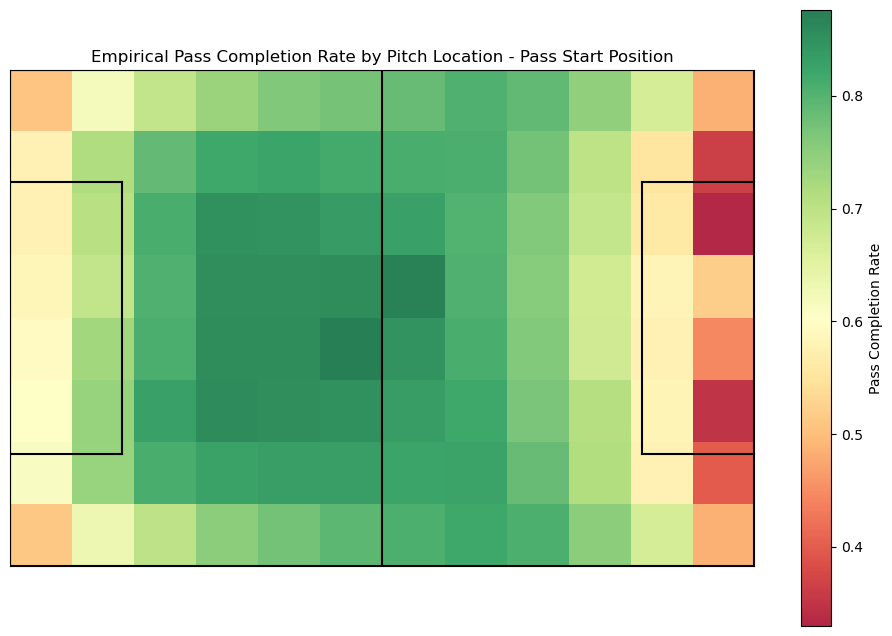

In [23]:
fig, ax = plt.subplots(figsize=(12, 8))

# Pitch outline. StatsBomb’s default pitch dimensions are 120x80
ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color="black")
ax.plot([60, 60], [0, 80], color="black")

# Penalty areas
ax.plot([102, 120], [18, 18], color="black")
ax.plot([102, 102], [18, 62], color="black")
ax.plot([102, 120], [62, 62], color="black")

ax.plot([0, 18], [18, 18], color="black")
ax.plot([18, 18], [18, 62], color="black")
ax.plot([0, 18], [62, 62], color="black")

# Heatmap of completion rate
im = ax.imshow(
    completion_grid_start.values,
    extent=[0, 120, 0, 80],
    origin="lower",
    cmap="RdYlGn", #RedYellowGreen
    alpha=0.85
)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pass Completion Rate")

# Formatting
ax.set_title("Empirical Pass Completion Rate by Pitch Location - Pass Start Position")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

plt.savefig("heatmap_start.png", dpi=300, bbox_inches="tight")

plt.show()

## Pass end position

In [25]:
# Define pitch bins (10-yard grid)
x_bins = np.linspace(0, 120, 13)
y_bins = np.linspace(0, 80, 9)

passes_clean["end_x_zone"] = pd.cut(passes_clean["end_x"], bins=x_bins, labels=False)
passes_clean["end_y_zone"] = pd.cut(passes_clean["end_y"], bins=y_bins, labels=False)

In [26]:
zone_stats_end = (
    passes_clean
    .groupby(["end_x_zone", "end_y_zone"])
    .agg(
        passes=("Outcome", "count"),           # total passes in the zone
        completion_rate=("Outcome", "mean")    # % of passes completed
    )
    .reset_index()
)

zone_stats_end.head()

,end_x_zone,end_y_zone,passes,completion_rate
0,0,0,1645,0.588450
1,0,1,1940,0.900000
2,0,2,3079,0.960702
3,0,3,7542,0.996022
4,0,4,8849,0.996271


In [27]:
completion_grid_end = zone_stats_end.pivot(
    index="end_y_zone",
    columns="end_x_zone",
    values="completion_rate"
)

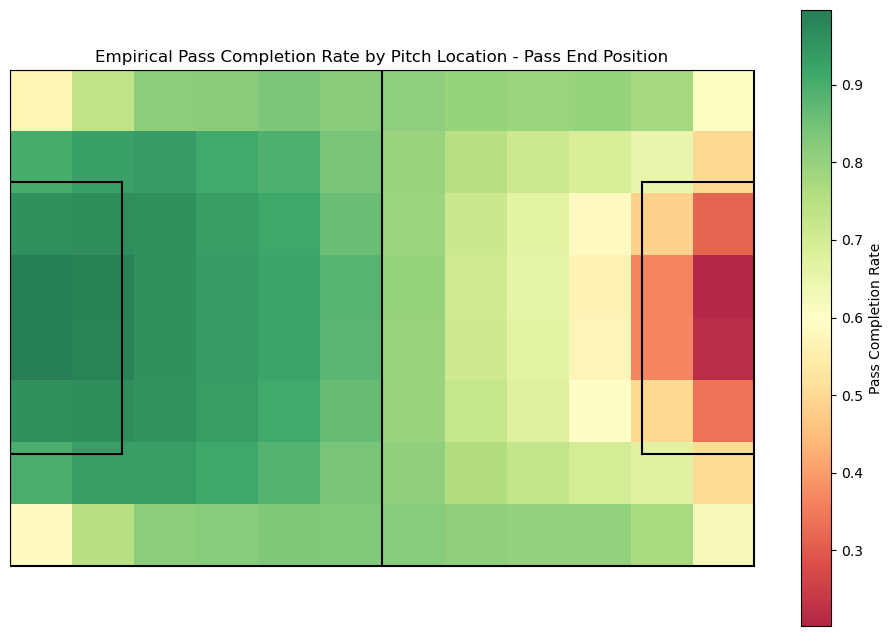

In [28]:
fig, ax = plt.subplots(figsize=(12, 8))

# Pitch outline
ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color="black")
ax.plot([60, 60], [0, 80], color="black")

# Penalty areas
ax.plot([102, 120], [18, 18], color="black")
ax.plot([102, 102], [18, 62], color="black")
ax.plot([102, 120], [62, 62], color="black")

ax.plot([0, 18], [18, 18], color="black")
ax.plot([18, 18], [18, 62], color="black")
ax.plot([0, 18], [62, 62], color="black")

# Heatmap of completion rate
im = ax.imshow(
    completion_grid_end.values,
    extent=[0, 120, 0, 80],
    origin="lower",
    cmap="RdYlGn",
    alpha=0.85
)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pass Completion Rate")

# Formatting
ax.set_title("Empirical Pass Completion Rate by Pitch Location - Pass End Position")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

plt.savefig("heatmap_end.png", dpi=300, bbox_inches="tight")

plt.show()

## Feature engineering

In [29]:
passes_clean["pass_type"] = passes_clean["pass_type"].fillna("Open Play")

In [30]:
passes_clean.loc[passes_clean["pass_type"] == "Throw-in", "pass_body_part"] = "Throw-in"

In [31]:
# Merge all feet and rare categories into Foot
passes_clean.loc[passes_clean["pass_body_part"].isin(
    ["Right Foot", "Left Foot", "Other", "Drop Kick", "Keeper Arm", "No Touch"]
), "pass_body_part"] = "Foot"

# Unknown body parts → Foot
passes_clean.loc[passes_clean["pass_body_part"].isna(), "pass_body_part"] = "Foot"

In [32]:
pd.crosstab(
    passes_clean["pass_body_part"],
    passes_clean["pass_type"],
    dropna=False
)

pass_type,Corner,Free Kick,Goal Kick,Interception,Kick Off,Open Play,Recovery,Throw-in
pass_body_part,,,,,,,,
Foot,17928,53597,29181,10574,8426,1346035,129724,0
Head,0,0,0,4752,0,26537,52155,0
Throw-in,0,0,0,0,0,0,0,83484


In [67]:
import pandas as pd
import numpy as np

def prepare_pass_features(df_passes):

    
    # Copy dataframe to avoid modifying original dataset
    
    df = df_passes.copy()

    
    # Binary flags (tag exists → 1, otherwise 0)
    
    binary_cols = [
        "under_pressure"
    ]

    for col in binary_cols:
        df[col] = df[col].notna().astype("int8")

    
    # Simplify body part
    
    df["body_clean"] = df["pass_body_part"]
    df["is_head"] = (df["body_clean"] == "Head")
    df["is_foot"] = (df["body_clean"] == "Foot")
    df = df.drop(columns=["pass_body_part", "body_clean"])

    
    # Context indicators
    
    setpiece_types = ["Throw-in", "Kick Off", "Goal Kick", "Free Kick", "Corner"]
    df["setpiece"] = df["pass_type"].isin(setpiece_types).astype("int8")
    df["regain"] = df["pass_type"].isin(["Recovery", "Interception"]).astype("int8")

    
    # Open play body combinations
    
    df["openplay_head"] = ((df["pass_type"] == "Open Play") & df["is_head"]).astype("int8")
    df["openplay_foot"] = ((df["pass_type"] == "Open Play") & df["is_foot"]).astype("int8")

    
    # Remove pass_type now that indicators are created
    
    df = df.drop(columns=["pass_type"])

    
    # Pass height feature
    
    df["high_pass"] = (df["pass_height"] == "High Pass").astype("int8")
    df = df.drop(columns=["pass_height"], errors="ignore")

    
    # Pass direction based on angle
    
    def map_direction(angle):
        if -np.pi/4 <= angle <= np.pi/4:
            return "Forward"
        elif np.pi/4 < angle <= 3*np.pi/4 or -3*np.pi/4 <= angle < -np.pi/4:
            return "Sideways"
        else:
            return "Backward"

    df["pass_direction"] = df["pass_angle"].apply(map_direction)
    df["Forward"] = (df["pass_direction"] == "Forward").astype("int8")
    df["Backward"] = (df["pass_direction"] == "Backward").astype("int8")
    df = df.drop(columns=["pass_direction"])

    
    # Binned pass length
    
    df["pass_length_bin"] = pd.cut(
        df["pass_length"],
        bins=[0, 15, 30, np.inf],
        labels=["short", "medium", "long"]
    )
    length_dummies = pd.get_dummies(df["pass_length_bin"], prefix="pass_length")
    df = pd.concat([df, length_dummies], axis=1)
    df = df.drop(columns=["pass_length", "pass_length_bin"])

    
    # Progression
    
    df["progression"] = df["end_x"] - df["start_x"]

    PITCH_MID = 120 / 2
    def is_progressive(row):
        if row["start_x"] < PITCH_MID and row["end_x"] < PITCH_MID:
            return row["progression"] >= 30
        elif row["start_x"] < PITCH_MID <= row["end_x"]:
            return row["progression"] >= 15
        elif row["start_x"] >= PITCH_MID:
            return row["progression"] >= 10
        else:
            return False

    df["progressive"] = df.apply(is_progressive, axis=1).astype("int8")

    
    # Pitch grid encoding
    
    df["start_square"] = df["start_x_zone"].astype(str) + "_" + df["start_y_zone"].astype(str)
    df["end_square"] = df["end_x_zone"].astype(str) + "_" + df["end_y_zone"].astype(str)
    all_squares = [f"{i}_{j}" for i in range(12) for j in range(8)]

    start_square_dummies = (
        pd.get_dummies(df["start_square"], prefix="sq_start")
        .reindex(columns=[f"sq_start_{s}" for s in all_squares], fill_value=0)
    )
    end_square_dummies = (
        pd.get_dummies(df["end_square"], prefix="sq_end")
        .reindex(columns=[f"sq_end_{s}" for s in all_squares], fill_value=0)
    )
    df = pd.concat([df, start_square_dummies, end_square_dummies], axis=1)

    
    # Feature list
    
    FEATURES = [
        "Forward",
        "Backward",
        "high_pass",
        "setpiece",
        "regain",
        "openplay_head",
        #"openplay_foot" baseline
        "pass_length_short",
        #"pass_length_medium", baseline
        "pass_length_long"
    ] + binary_cols + list(start_square_dummies.columns) + list(end_square_dummies.columns)

    
    # Metadata
    
    META_COLS = ["match_id", "team", "player", "pass_recipient"]
    meta = df[[c for c in META_COLS if c in df.columns]].copy()

    
    # Model matrices
    
    X = df[FEATURES]
    y = df["Outcome"]

    return df, X, y, FEATURES, meta

In [87]:
df, X, y, FEATURES, meta = prepare_pass_features(passes_clean)

In [88]:
df.head(3)

,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,competition_x,competition_y,match_date,match_week,home_team,away_team,home_score,away_score,start_x,start_y,end_x,end_y,Outcome,start_x_zone,start_y_zone,end_x_zone,end_y_zone,is_head,is_foot,setpiece,regain,openplay_head,openplay_foot,high_pass,Forward,Backward,pass_length_short,pass_length_medium,pass_length_long,progression,progressive,start_square,end_square,sq_start_0_0,sq_start_0_1,sq_start_0_2,sq_start_0_3,sq_start_0_4,sq_start_0_5,sq_start_0_6,sq_start_0_7,sq_start_1_0,sq_start_1_1,sq_start_1_2,sq_start_1_3,sq_start_1_4,sq_start_1_5,sq_start_1_6,sq_start_1_7,sq_start_2_0,sq_start_2_1,sq_start_2_2,sq_start_2_3,sq_start_2_4,sq_start_2_5,sq_start_2_6,sq_start_2_7,sq_start_3_0,sq_start_3_1,sq_start_3_2,sq_start_3_3,sq_start_3_4,sq_start_3_5,sq_start_3_6,sq_start_3_7,sq_start_4_0,sq_start_4_1,sq_start_4_2,sq_start_4_3,sq_start_4_4,sq_start_4_5,sq_start_4_6,sq_start_4_7,sq_start_5_0,sq_start_5_1,sq_start_5_2,sq_start_5_3,sq_start_5_4,sq_start_5_5,sq_start_5_6,sq_start_5_7,sq_start_6_0,sq_start_6_1,sq_start_6_2,sq_start_6_3,sq_start_6_4,sq_start_6_5,sq_start_6_6,sq_start_6_7,sq_start_7_0,sq_start_7_1,sq_start_7_2,sq_start_7_3,sq_start_7_4,sq_start_7_5,sq_start_7_6,sq_start_7_7,sq_start_8_0,sq_start_8_1,sq_start_8_2,sq_start_8_3,sq_start_8_4,sq_start_8_5,sq_start_8_6,sq_start_8_7,sq_start_9_0,sq_start_9_1,sq_start_9_2,sq_start_9_3,sq_start_9_4,sq_start_9_5,sq_start_9_6,sq_start_9_7,sq_start_10_0,sq_start_10_1,sq_start_10_2,sq_start_10_3,sq_start_10_4,sq_start_10_5,sq_start_10_6,sq_start_10_7,sq_start_11_0,sq_start_11_1,sq_start_11_2,sq_start_11_3,sq_start_11_4,sq_start_11_5,sq_start_11_6,sq_start_11_7,sq_end_0_0,sq_end_0_1,sq_end_0_2,sq_end_0_3,sq_end_0_4,sq_end_0_5,sq_end_0_6,sq_end_0_7,sq_end_1_0,sq_end_1_1,sq_end_1_2,sq_end_1_3,sq_end_1_4,sq_end_1_5,sq_end_1_6,sq_end_1_7,sq_end_2_0,sq_end_2_1,sq_end_2_2,sq_end_2_3,sq_end_2_4,sq_end_2_5,sq_end_2_6,sq_end_2_7,sq_end_3_0,sq_end_3_1,sq_end_3_2,sq_end_3_3,sq_end_3_4,sq_end_3_5,sq_end_3_6,sq_end_3_7,sq_end_4_0,sq_end_4_1,sq_end_4_2,sq_end_4_3,sq_end_4_4,sq_end_4_5,sq_end_4_6,sq_end_4_7,sq_end_5_0,sq_end_5_1,sq_end_5_2,sq_end_5_3,sq_end_5_4,sq_end_5_5,sq_end_5_6,sq_end_5_7,sq_end_6_0,sq_end_6_1,sq_end_6_2,sq_end_6_3,sq_end_6_4,sq_end_6_5,sq_end_6_6,sq_end_6_7,sq_end_7_0,sq_end_7_1,sq_end_7_2,sq_end_7_3,sq_end_7_4,sq_end_7_5,sq_end_7_6,sq_end_7_7,sq_end_8_0,sq_end_8_1,sq_end_8_2,sq_end_8_3,sq_end_8_4,sq_end_8_5,sq_end_8_6,sq_end_8_7,sq_end_9_0,sq_end_9_1,sq_end_9_2,sq_end_9_3,sq_end_9_4,sq_end_9_5,sq_end_9_6,sq_end_9_7,sq_end_10_0,sq_end_10_1,sq_end_10_2,sq_end_10_3,sq_end_10_4,sq_end_10_5,sq_end_10_6,sq_end_10_7,sq_end_11_0,sq_end_11_1,sq_end_11_2,sq_end_11_3,sq_end_11_4,sq_end_11_5,sq_end_11_6,sq_end_11_7
0,NaN,0.462911,819a652e-ec2e-408b-9c40-253c2be88817,5,[61. 40.1],3879863,0,NaN,NaN,NaN,2.425849,NaN,NaN,NaN,[58.7 42.1],NaN,NaN,NaN,Complete,NaN,Luca Cigarini,8420.0,NaN,NaN,NaN,1,From Kick Off,Marten de Roon,6994.0,Left Defensive Midfield,2,Atalanta,228,['48c2d1ac-974b-49ae-ad53-d67d7d4964ed'],0,Atalanta,228,00:00:00.556,Pass,0,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1,61.0,40.1,58.7,42.1,1,6,4,5,4,False,True,1,0,0,0,0,0,1,True,False,False,-2.3,0,6_4,5_4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fa

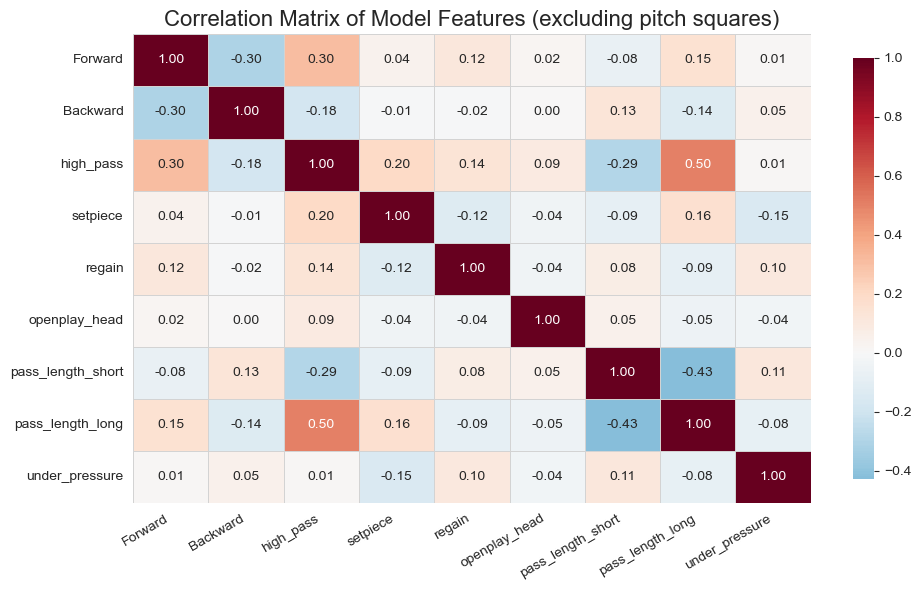

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only features that do NOT start with 'sq_'
features_no_sq = [f for f in FEATURES if not f.startswith("sq_")]

corr = X[features_no_sq].corr()

# Clean plotting style
sns.set_style("white")

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    linecolor="lightgray",
    cbar_kws={"shrink":0.9}
)

plt.title("Correlation Matrix of Model Features (excluding pitch squares)", fontsize=16)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Train global xP model

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss
import pandas as pd


# Train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=14
)


# Feature scaling (normalisation)

scaler = StandardScaler()

# Fit on training set only
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Fit expected pass completion model

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [91]:
# Predict probabilities

y_train_pred_prob = model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_prob = model.predict_proba(X_test_scaled)[:, 1]


# Evaluate performance

from sklearn.metrics import roc_auc_score, brier_score_loss

# Train
auc_train = roc_auc_score(y_train, y_train_pred_prob)
brier_train = brier_score_loss(y_train, y_train_pred_prob)

# Test
auc_test = roc_auc_score(y_test, y_test_pred_prob)
brier_test = brier_score_loss(y_test, y_test_pred_prob)

print("TRAIN AUC:", auc_train)
print("TRAIN Brier score:", brier_train)
print("TEST AUC:", auc_test)
print("TEST Brier score:", brier_test)


# Coefficient inspection

import pandas as pd

pd.set_option('display.max_rows', None)

coef_table = pd.DataFrame({
    "feature": X.columns,
    "coef": model.coef_[0]
}).sort_values("coef")

# Remove pitch square features for readability
coef_table_filtered = coef_table[~coef_table["feature"].str.startswith("sq_")]

print(coef_table_filtered)

TRAIN AUC: 0.8636446634576032
TRAIN Brier score: 0.11860317379533747
TEST AUC: 0.8633919454282472
TEST Brier score: 0.11847351793853371
             feature      coef
2          high_pass -0.502290
0            Forward -0.322740
8     under_pressure -0.268703
4             regain -0.199280
6  pass_length_short -0.193843
5      openplay_head -0.147767
7   pass_length_long -0.037749
1           Backward  0.210699
3           setpiece  0.225783


Feature impacts on pass completion (odds ratio):


C:\Users\vicky\AppData\Local\Temp\ipykernel_15476\1881567390.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coef_table_filtered["odds_ratio"] = np.exp(coef_table_filtered["coef"])
C:\Users\vicky\AppData\Local\Temp\ipykernel_15476\1881567390.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  coef_table_filtered["impact"] = coef_table_filtered["coef"].apply(lambda x: "decrease" if x < 0 else "increase")


,feature,coef,odds_ratio,impact
2,high_pass,-0.502290,0.605143,decrease
0,Forward,-0.322740,0.724162,decrease
8,under_pressure,-0.268703,0.764371,decrease
3,setpiece,0.225783,1.253304,increase
1,Backward,0.210699,1.234541,increase
4,regain,-0.199280,0.819320,decrease
6,pass_length_short,-0.193843,0.823787,decrease
5,openplay_head,-0.147767,0.862632,decrease
7,pass_length_long,-0.037749,0.962954,decrease


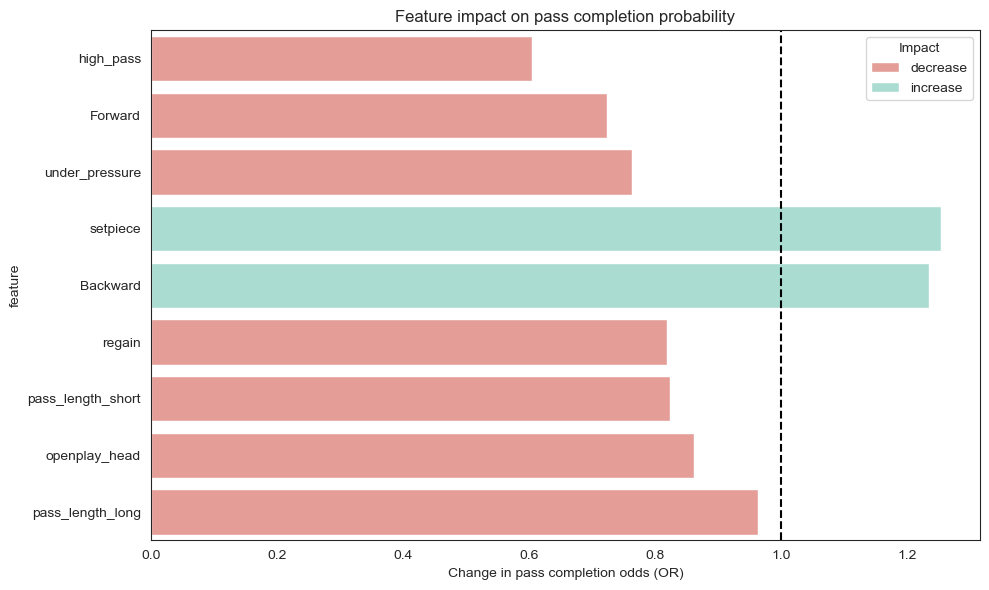

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Feature coefficients table with odds ratios

coef_table_filtered["odds_ratio"] = np.exp(coef_table_filtered["coef"])
coef_table_filtered["impact"] = coef_table_filtered["coef"].apply(lambda x: "decrease" if x < 0 else "increase")
coef_table_filtered_sorted = coef_table_filtered.reindex(
    coef_table_filtered["coef"].abs().sort_values(ascending=False).index
)

print("Feature impacts on pass completion (odds ratio):")
display(coef_table_filtered_sorted)


# 2. Plot coefficients (odds ratio) with clear label and pastel colors

plt.figure(figsize=(10,6))
sns.barplot(
    data=coef_table_filtered_sorted,
    x="odds_ratio",
    y="feature",
    hue="impact",
    dodge=False,
    palette={"increase": "#A3E4D7", "decrease": "#F1948A"}  # pastel green/red
)
plt.axvline(1, color="black", linestyle="--")
plt.xlabel("Change in pass completion odds (OR)")
plt.title("Feature impact on pass completion probability")
plt.legend(title="Impact")
plt.tight_layout()
plt.show()


# 3. Function to predict xP and contributions safely

def predict_xp(example_features, model, X_columns, scaler=None):
    # Fill missing columns with 0 and preserve order
    full_example = {f: example_features.get(f, 0) for f in X_columns}
    df_example = pd.DataFrame([full_example])[X_columns]
    
    # Scale if needed
    X_scaled = scaler.transform(df_example) if scaler is not None else df_example.values
    
    # Coefficients and contributions
    coefs = model.coef_[0]
    contributions = X_scaled[0] * coefs
    contributions_df = pd.DataFrame({
        "feature": X_columns,
        "feature_value": X_scaled[0],
        "coef": coefs,
        "contribution": contributions
    }).sort_values("contribution", key=abs, ascending=False)
    
    # Total log-odds and probability
    log_odds = contributions.sum() + model.intercept_[0]
    prob = 1 / (1 + np.exp(-log_odds))
    
    return prob, log_odds, contributions_df


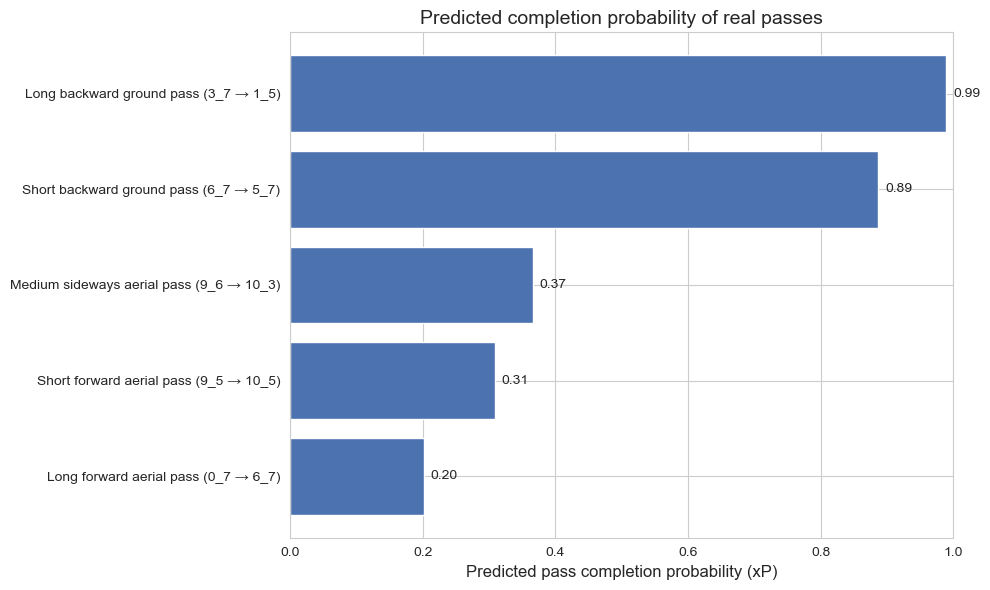

In [93]:
# Function to predict xPass probability


def predict_xp(example_features, model, X_columns, scaler=None):

    df_example = pd.DataFrame([example_features])[X_columns]

    if scaler is not None:
        X_scaled = scaler.transform(df_example)
    else:
        X_scaled = df_example.values

    prob = model.predict_proba(X_scaled)[0][1]

    return prob



# Function to describe pass characteristics


def describe_pass(row):

    if row["pass_length_short"] == 1:
        length = "Short"
    elif row["pass_length_long"] == 1:
        length = "Long"
    else:
        length = "Medium"

    if row["Forward"] == 1:
        direction = "forward"
    elif row["Backward"] == 1:
        direction = "backward"
    else:
        direction = "sideways"

    height = "aerial" if row["high_pass"] == 1 else "ground"

    pressure = " under pressure" if row["under_pressure"] == 1 else ""

    return f"{length} {direction} {height} pass{pressure}"



# Sample REAL passes


sample_passes = df.sample(5, random_state=14).copy()

results = []

for _, row in sample_passes.iterrows():

    features = row[X.columns].to_dict()

    prob = predict_xp(
        features,
        model,
        X.columns,
        scaler=scaler if 'scaler' in globals() else None
    )

    desc = describe_pass(row)

    label = f"{desc} ({row['start_square']} → {row['end_square']})"

    results.append((label, prob))



# Sort passes by xPass


results = sorted(results, key=lambda x: x[1])

names = [r[0] for r in results]
probs = [r[1] for r in results]



# Plot


sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

bars = plt.barh(
    names,
    probs,
    color="#4C72B0"  # single clean blue colour
)

plt.xlim(0,1)

plt.xlabel("Predicted pass completion probability (xP)", fontsize=12)
plt.title("Predicted completion probability of real passes", fontsize=14)

# Annotate probabilities
for bar, prob in zip(bars, probs):

    plt.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{prob:.2f}",
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

# Calibration

In [94]:
# Prepare feature matrix

X_full = df[X.columns]

if 'scaler' in globals():
    X_scaled = scaler.transform(X_full)
else:
    X_scaled = X_full.values


# Predict probabilities

df["xP"] = model.predict_proba(X_scaled)[:,1]

In [95]:
df.head()

,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,competition_x,competition_y,match_date,match_week,home_team,away_team,home_score,away_score,start_x,start_y,end_x,end_y,Outcome,start_x_zone,start_y_zone,end_x_zone,end_y_zone,is_head,is_foot,setpiece,regain,openplay_head,openplay_foot,high_pass,Forward,Backward,pass_length_short,pass_length_medium,pass_length_long,progression,progressive,start_square,end_square,sq_start_0_0,sq_start_0_1,sq_start_0_2,sq_start_0_3,sq_start_0_4,sq_start_0_5,sq_start_0_6,sq_start_0_7,sq_start_1_0,sq_start_1_1,sq_start_1_2,sq_start_1_3,sq_start_1_4,sq_start_1_5,sq_start_1_6,sq_start_1_7,sq_start_2_0,sq_start_2_1,sq_start_2_2,sq_start_2_3,sq_start_2_4,sq_start_2_5,sq_start_2_6,sq_start_2_7,sq_start_3_0,sq_start_3_1,sq_start_3_2,sq_start_3_3,sq_start_3_4,sq_start_3_5,sq_start_3_6,sq_start_3_7,sq_start_4_0,sq_start_4_1,sq_start_4_2,sq_start_4_3,sq_start_4_4,sq_start_4_5,sq_start_4_6,sq_start_4_7,sq_start_5_0,sq_start_5_1,sq_start_5_2,sq_start_5_3,sq_start_5_4,sq_start_5_5,sq_start_5_6,sq_start_5_7,sq_start_6_0,sq_start_6_1,sq_start_6_2,sq_start_6_3,sq_start_6_4,sq_start_6_5,sq_start_6_6,sq_start_6_7,sq_start_7_0,sq_start_7_1,sq_start_7_2,sq_start_7_3,sq_start_7_4,sq_start_7_5,sq_start_7_6,sq_start_7_7,sq_start_8_0,sq_start_8_1,sq_start_8_2,sq_start_8_3,sq_start_8_4,sq_start_8_5,sq_start_8_6,sq_start_8_7,sq_start_9_0,sq_start_9_1,sq_start_9_2,sq_start_9_3,sq_start_9_4,sq_start_9_5,sq_start_9_6,sq_start_9_7,sq_start_10_0,sq_start_10_1,sq_start_10_2,sq_start_10_3,sq_start_10_4,sq_start_10_5,sq_start_10_6,sq_start_10_7,sq_start_11_0,sq_start_11_1,sq_start_11_2,sq_start_11_3,sq_start_11_4,sq_start_11_5,sq_start_11_6,sq_start_11_7,sq_end_0_0,sq_end_0_1,sq_end_0_2,sq_end_0_3,sq_end_0_4,sq_end_0_5,sq_end_0_6,sq_end_0_7,sq_end_1_0,sq_end_1_1,sq_end_1_2,sq_end_1_3,sq_end_1_4,sq_end_1_5,sq_end_1_6,sq_end_1_7,sq_end_2_0,sq_end_2_1,sq_end_2_2,sq_end_2_3,sq_end_2_4,sq_end_2_5,sq_end_2_6,sq_end_2_7,sq_end_3_0,sq_end_3_1,sq_end_3_2,sq_end_3_3,sq_end_3_4,sq_end_3_5,sq_end_3_6,sq_end_3_7,sq_end_4_0,sq_end_4_1,sq_end_4_2,sq_end_4_3,sq_end_4_4,sq_end_4_5,sq_end_4_6,sq_end_4_7,sq_end_5_0,sq_end_5_1,sq_end_5_2,sq_end_5_3,sq_end_5_4,sq_end_5_5,sq_end_5_6,sq_end_5_7,sq_end_6_0,sq_end_6_1,sq_end_6_2,sq_end_6_3,sq_end_6_4,sq_end_6_5,sq_end_6_6,sq_end_6_7,sq_end_7_0,sq_end_7_1,sq_end_7_2,sq_end_7_3,sq_end_7_4,sq_end_7_5,sq_end_7_6,sq_end_7_7,sq_end_8_0,sq_end_8_1,sq_end_8_2,sq_end_8_3,sq_end_8_4,sq_end_8_5,sq_end_8_6,sq_end_8_7,sq_end_9_0,sq_end_9_1,sq_end_9_2,sq_end_9_3,sq_end_9_4,sq_end_9_5,sq_end_9_6,sq_end_9_7,sq_end_10_0,sq_end_10_1,sq_end_10_2,sq_end_10_3,sq_end_10_4,sq_end_10_5,sq_end_10_6,sq_end_10_7,sq_end_11_0,sq_end_11_1,sq_end_11_2,sq_end_11_3,sq_end_11_4,sq_end_11_5,sq_end_11_6,sq_end_11_7,xP
0,NaN,0.462911,819a652e-ec2e-408b-9c40-253c2be88817,5,[61. 40.1],3879863,0,NaN,NaN,NaN,2.425849,NaN,NaN,NaN,[58.7 42.1],NaN,NaN,NaN,Complete,NaN,Luca Cigarini,8420.0,NaN,NaN,NaN,1,From Kick Off,Marten de Roon,6994.0,Left Defensive Midfield,2,Atalanta,228,['48c2d1ac-974b-49ae-ad53-d67d7d4964ed'],0,Atalanta,228,00:00:00.556,Pass,0,NaN,NaN,NaN,NaN,Italy - Serie A,Italy - Serie A,2016-05-08,37,Atalanta,Udinese,1,1,61.0,40.1,58.7,42.1,1,6,4,5,4,False,True,1,0,0,0,0,0,1,True,False,False,-2.3,0,6_4,5_4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

In [96]:
df = (
    df
    #.drop(columns=[col for col in df.columns 
    #               if col.startswith("sq_start_") or col.startswith("sq_end_")])  # remove square dummies
    .assign(competition=lambda x: x["competition_x"])  # create single competition column
    .drop(columns=["competition_x", "competition_y"])  # remove duplicates
)

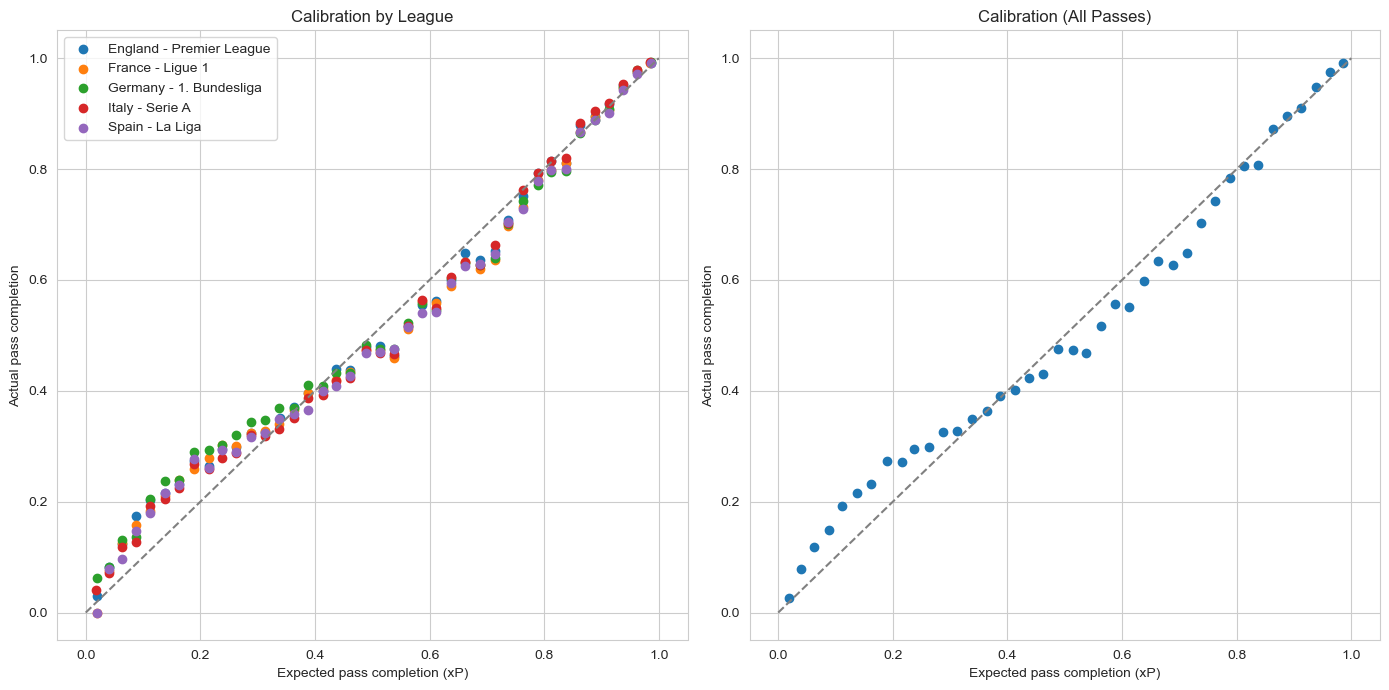

In [97]:
# --
# Calibration scatter plots
# --

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Function to compute calibration bins
def calibration_bins(df, bins=40):

    df = df.copy()

    df["xP_bin"] = pd.cut(df["xP"], bins=np.linspace(0, 1, bins + 1))

    calib = (
        df.groupby("xP_bin", observed=True)
        .agg(
            expected_xP=("xP", "mean"),
            actual_completion=("Outcome", "mean"),
            n_passes=("Outcome", "size")
        )
        .dropna()
        .reset_index()
    )

    return calib


# --
# Create side-by-side plots
# --

fig, axes = plt.subplots(1, 2, figsize=(14,7))

# --------------------------------
# 1️⃣ Calibration by league
# --------------------------------

for league, data in df.groupby("competition"):

    calib = calibration_bins(data, bins=40)

    axes[0].scatter(
        calib["expected_xP"],
        calib["actual_completion"],
        label=league
    )

axes[0].plot([0,1], [0,1], linestyle="--", color="grey")

axes[0].set_xlabel("Expected pass completion (xP)")
axes[0].set_ylabel("Actual pass completion")
axes[0].set_title("Calibration by League")
axes[0].legend()


# --------------------------------
# 2️⃣ Calibration all passes
# --------------------------------

calib_all = calibration_bins(df, bins=40)

axes[1].scatter(
    calib_all["expected_xP"],
    calib_all["actual_completion"]
)

axes[1].plot([0,1], [0,1], linestyle="--", color="grey")

axes[1].set_xlabel("Expected pass completion (xP)")
axes[1].set_ylabel("Actual pass completion")
axes[1].set_title("Calibration (All Passes)")


plt.tight_layout()
plt.show()

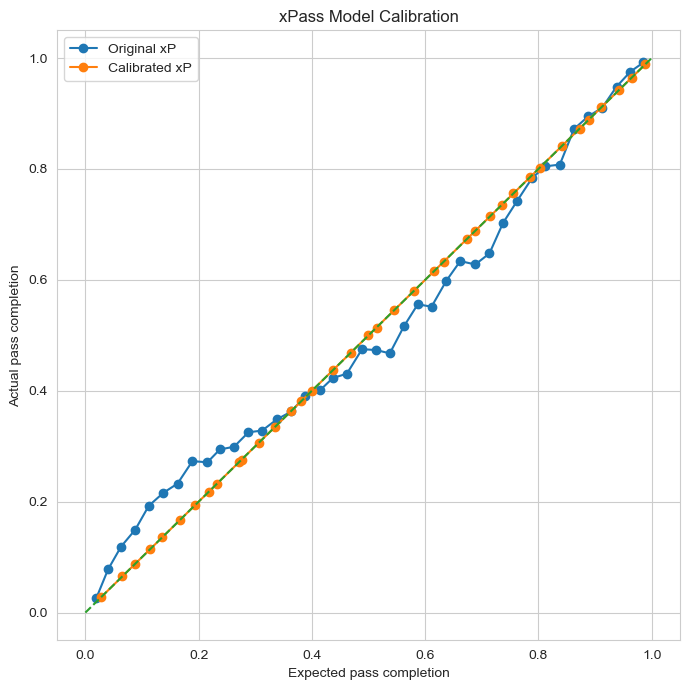

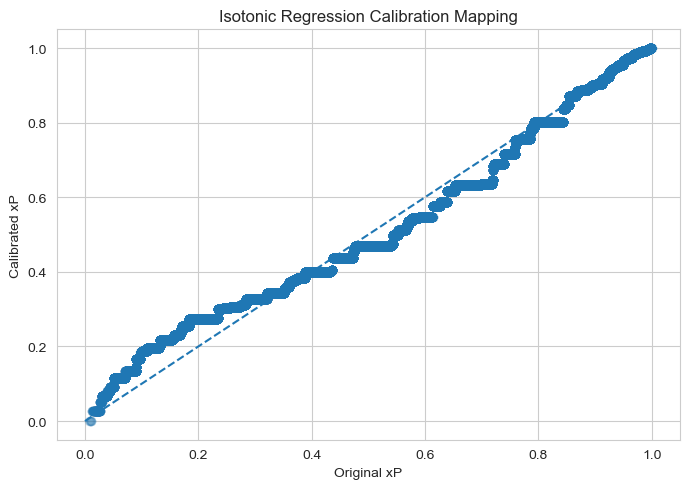

In [98]:
# --------------------------------------------------
# xPass Calibration using Isotonic Regression
# --------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.isotonic import IsotonicRegression


# --------------------------------------------------
# 1️⃣ Fit isotonic regression calibration model
# --------------------------------------------------
# We learn a monotonic mapping between predicted
# probabilities (xP) and actual outcomes (0/1).

iso_model = IsotonicRegression(out_of_bounds="clip")

iso_model.fit(
    df["xP"],        # model predicted probability
    df["Outcome"]    # actual pass completion (0/1)
)


# --------------------------------------------------
# 2️⃣ Create calibrated probabilities
# --------------------------------------------------
# This adjusts the original xP so that predicted
# probabilities better match empirical frequencies.

df["xP_calibrated"] = iso_model.predict(df["xP"])


# --------------------------------------------------
# 3️⃣ Function to compute calibration bins
# --------------------------------------------------
# Groups passes into probability bins and compares
# expected vs actual completion.

def calibration_bins(df, prob_col="xP", bins=40):

    temp = df.copy()

    temp["xP_bin"] = pd.cut(
        temp[prob_col],
        bins=np.linspace(0, 1, bins + 1)
    )

    calib = (
        temp.groupby("xP_bin", observed=True)
        .agg(
            expected_xP=(prob_col, "mean"),
            actual_completion=("Outcome", "mean"),
            n_passes=("Outcome", "size")
        )
        .dropna()
        .reset_index()
    )

    return calib


# --------------------------------------------------
# 4️⃣ Compute calibration curves
# --------------------------------------------------

calib_before = calibration_bins(df, prob_col="xP")
calib_after = calibration_bins(df, prob_col="xP_calibrated")


# --------------------------------------------------
# 5️⃣ Plot calibration before vs after correction
# --------------------------------------------------

plt.figure(figsize=(7,7))

plt.plot(
    calib_before["expected_xP"],
    calib_before["actual_completion"],
    marker="o",
    label="Original xP"
)

plt.plot(
    calib_after["expected_xP"],
    calib_after["actual_completion"],
    marker="o",
    label="Calibrated xP"
)

# perfect calibration line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("Expected pass completion")
plt.ylabel("Actual pass completion")
plt.title("xPass Model Calibration")

plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 6️⃣ Visualise the isotonic calibration mapping
# --------------------------------------------------
# This shows how probabilities were adjusted.

plt.figure(figsize=(7,5))

plt.scatter(
    df["xP"],
    df["xP_calibrated"],
    alpha=0.05
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("Original xP")
plt.ylabel("Calibrated xP")
plt.title("Isotonic Regression Calibration Mapping")

plt.tight_layout()
plt.show()

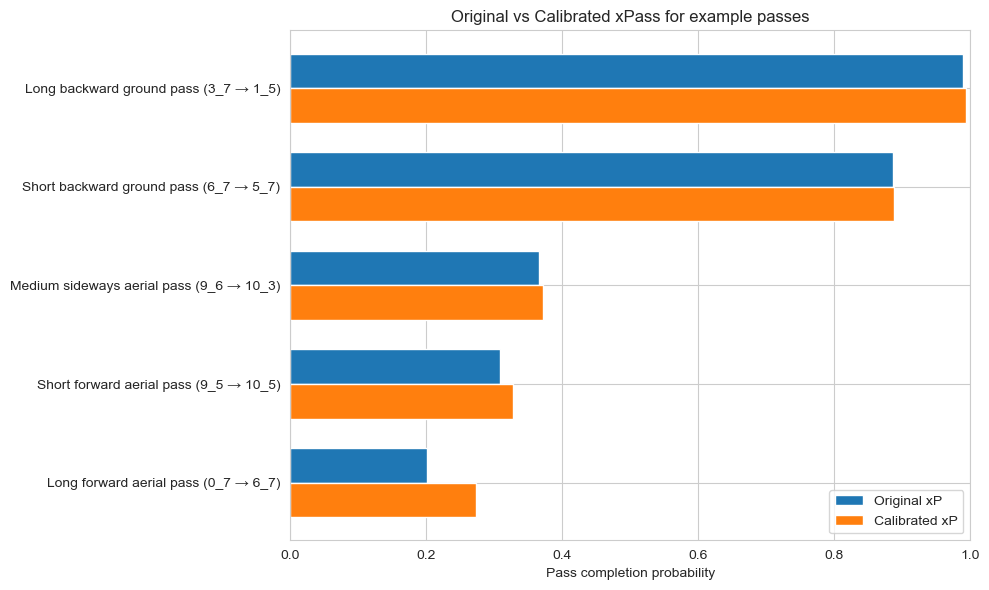

In [99]:
# --------------------------------------------------
# Compare original xPass vs calibrated xPass
# for a few example passes
# --------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Function to predict xPass probability
# --------------------------------------------------

def predict_xp(example_features, model, X_columns, scaler=None):

    df_example = pd.DataFrame([example_features])[X_columns]

    if scaler is not None:
        X_scaled = scaler.transform(df_example)
    else:
        X_scaled = df_example.values

    prob = model.predict_proba(X_scaled)[0][1]

    return prob


# --------------------------------------------------
# Function to describe pass characteristics
# --------------------------------------------------

def describe_pass(row):

    # pass length
    if row["pass_length_short"] == 1:
        length = "Short"
    elif row["pass_length_long"] == 1:
        length = "Long"
    else:
        length = "Medium"

    # pass direction
    if row["Forward"] == 1:
        direction = "forward"
    elif row["Backward"] == 1:
        direction = "backward"
    else:
        direction = "sideways"

    # height
    height = "aerial" if row["high_pass"] == 1 else "ground"

    # pressure
    pressure = " under pressure" if row["under_pressure"] == 1 else ""

    return f"{length} {direction} {height} pass{pressure}"


# --------------------------------------------------
# Sample real passes from dataset
# --------------------------------------------------

sample_passes = df.sample(5, random_state=14).copy()

results = []

for _, row in sample_passes.iterrows():

    # extract model features
    features = row[X.columns].to_dict()

    # original model prediction
    prob = predict_xp(
        features,
        model,
        X.columns,
        scaler=scaler if 'scaler' in globals() else None
    )

    # calibrated probability using isotonic regression
    prob_cal = iso_model.predict([prob])[0]

    # description of pass
    desc = describe_pass(row)

    label = f"{desc} ({row['start_square']} → {row['end_square']})"

    results.append((label, prob, prob_cal))


# --------------------------------------------------
# Sort by original xPass
# --------------------------------------------------

results = sorted(results, key=lambda x: x[1])

names = [r[0] for r in results]
xp_old = [r[1] for r in results]
xp_new = [r[2] for r in results]


# --------------------------------------------------
# Plot comparison
# --------------------------------------------------

sns.set_style("whitegrid")

y_pos = range(len(names))
bar_height = 0.35

plt.figure(figsize=(10,6))

# original xPass
plt.barh(
    [y + bar_height/2 for y in y_pos],
    xp_old,
    height=bar_height,
    label="Original xP"
)

# calibrated xPass
plt.barh(
    [y - bar_height/2 for y in y_pos],
    xp_new,
    height=bar_height,
    label="Calibrated xP"
)

plt.yticks(y_pos, names)
plt.xlim(0,1)

plt.xlabel("Pass completion probability")
plt.title("Original vs Calibrated xPass for example passes")

plt.legend()

plt.tight_layout()
plt.show()

## Apply the xP model to Premier League

In [101]:
# --------------------------------------------------
# Clean Premier League dataset (using calibrated xPass)
# --------------------------------------------------

# Filter Premier League passes
pl_df = (
    df[df["competition"] == "England - Premier League"]
    
    # Remove start/end square dummy variables
    .drop(columns=[col for col in df.columns
                   if col.startswith("sq_start_") or col.startswith("sq_end_")])
    
    .copy()
)

# Remove set pieces
pl_df = pl_df[pl_df["setpiece"] == 0]

# Reset index
pl_df = pl_df.reset_index(drop=True)

# Use calibrated xPass as the main probability
pl_df["xP"] = pl_df["xP_calibrated"]

# Quick check
print("Dataset shape:", pl_df.shape)

pl_df.head()

Dataset shape: (327928, 78)


,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,match_date,match_week,home_team,away_team,home_score,away_score,start_x,start_y,end_x,end_y,Outcome,start_x_zone,start_y_zone,end_x_zone,end_y_zone,is_head,is_foot,setpiece,regain,openplay_head,openplay_foot,high_pass,Forward,Backward,pass_length_short,pass_length_medium,pass_length_long,progression,progressive,start_square,end_square,xP,competition,xP_calibrated
0,NaN,0.933203,0fee7719-7e69-49c5-be81-3f2b77da604e,8,[60.4 43.6],3754058,0,NaN,NaN,NaN,-2.989549,NaN,NaN,NaN,[48. 41.7],NaN,NaN,NaN,Complete,NaN,Andrew Surman,3344.0,NaN,NaN,NaN,1,From Kick Off,Joshua King,3346.0,Center Forward,2,AFC Bournemouth,28,['8764f645-0544-426e-9bef-764dcf13f019'],2,AFC Bournemouth,28,00:00:02.077,Pass,0,NaN,NaN,NaN,NaN,2016-01-02,20,Leicester City,AFC Bournemouth,0,0,60.4,43.6,48.0,41.7,1,6,4,4,4,False,True,0,0,0,1,0,0,1,True,False,False,-12.4,0,6_4,4_4,0.992964,England - Premier League,0.992964
1,NaN,2.454046,6362aa69-892f-4d11-8644-21a680ea7c66,10,[48. 41.7],3754058,0,NaN,NaN,NaN,1.867047,NaN,NaN,NaN,[37.5 76.1],NaN,NaN,NaN,Complete,NaN,Adam Smith,6409.0,NaN,NaN,NaN,1,From Kick Off,Andrew Surman,3344.0,Center Defensive Midfield,2,AFC Bournemouth,28,['4e43a985-9566-4762-868f-c992de243bd6'],3,AFC Bournemouth,28,00:00:03.010,Pass,0,NaN,NaN,NaN,NaN,2016-01-02,20,Leicester City,AFC Bournemouth,0,0,48.0,41.7,37.5,76.1,1,4,4,3,7,False,True,0,0,0,1,0,0,0,False,False,True,-10.5,0,4_4,3_7,0.982862,England - Premier League,0.982862
2,NaN,1.795575,56da36e4-8b0d-4596-ba46-1d944c3d3f04,13,[37.5 74.6],3754058,0,NaN,NaN,NaN,-2.120081,NaN,NaN,NaN,[27.4 58.1],NaN,NaN,NaN,Complete,NaN,Simon Francis,3608.0,NaN,NaN,NaN,1,From Kick Off,Adam Smith,6409.0,Right Back,2,AFC Bournemouth,28,['a4eb31c9-6417-4a65-9f71-b3aeece1758e'],6,AFC Bournemouth,28,00:00:06.145,Pass,0,NaN,NaN,NaN,NaN,2016-01-02,20,Leicester City,AFC Bournemouth,0,0,37.5,74.6,27.4,58.1,1,3,7,2,5,False,True,0,0,0,1,0,0,0,False,True,False,-10.1,0,3_7,2_5,0.989358,England - Premier League,0.989358
3,NaN,1.111890,bcfea2e3-9736-4975-be28-ef2c9d693fa7,16,[27.4 63.9],3754058,0,NaN,NaN,NaN,1.064920,NaN,NaN,NaN,[35.1 77.8],NaN,NaN,NaN,Complete,NaN,Adam Smith,6409.0,NaN,NaN,NaN,1,From Kick Off,Simon Francis,3608.0,Right Center Back,2,AFC Bournemouth,28,['4b427f4b-296d-4967-a419-b6b480fe50e2'],9,AFC Bournemouth,28,00:00:09.350,Pass,0,NaN,NaN,NaN,NaN,2016-01-02,20,Leicester City,AFC Bournemouth,0,0,27.4,63.9,35.1,77.8,1,2,6,3,7,False,True,0,0,0,1,0,0,0,False,True,False,7.7,0,2_6,3_7,0.939531,England - Premier League,0.939531
4,NaN,1.199999,080be99c-fea7-495b-8230-cbd0b34294ac,20,[30.4 78. ],3754058,0,NaN,NaN,NaN,-2.961097,NaN,NaN,NaN,[16.7 75.5],NaN,NaN,NaN,Complete,NaN,Simon Francis,3608.0,NaN,NaN,NaN,1,From Kick Off,Adam Smith,6409.0,Right Back,2,AFC Bournemouth,28,['9936fb68-646b-4195-91ab-af802c81dd33'],12,AFC Bournemouth,28,00:00:12.746,Pass,0,NaN,NaN,NaN,NaN,2016-01-02,20,Leicester City,AFC Bournemouth,0,0,30.4,78.0,16.7,75.5,1,3,7,1,7,False,True,0,0,0,1,0,0,1,True,False,False,-13.7,0,3_7,1_7,0.942686,England - Premier League,0.942686


In [111]:
# --------------------------------------------------
# Analyse xPass performance
# Works with calibrated or original probabilities
# --------------------------------------------------

def analyse_xpass(df, prob_col="xP_calibrated"):

    df_use = df.copy()

    # --------------------------------------------------
    # TEAM LEVEL
    # --------------------------------------------------
    team_stats = (
        df_use.groupby("team")
        .agg(
            total_passes=("Outcome", "count"),
            completed_passes=("Outcome", "sum"),
            total_xP=(prob_col, "sum")
        )
        .reset_index()
    )

    team_stats["actual_completion_rate"] = (
        team_stats["completed_passes"] / team_stats["total_passes"]
    )

    team_stats["expected_completion_rate"] = (
        team_stats["total_xP"] / team_stats["total_passes"]
    )

    team_stats["overperformance"] = (
        team_stats["completed_passes"] - team_stats["total_xP"]
    )

    team_stats["overperformance_per_pass"] = (
        team_stats["overperformance"] / team_stats["total_passes"]
    )


    # --------------------------------------------------
    # PLAYER LEVEL
    # --------------------------------------------------
    player_stats = (
        df_use.groupby(["player", "team"])
        .agg(
            position=("position", "first"),   # include position
            total_passes=("Outcome", "count"),
            completed_passes=("Outcome", "sum"),
            total_xP=(prob_col, "sum")
        )
        .reset_index()
    )

    player_stats["actual_completion_rate"] = (
        player_stats["completed_passes"] / player_stats["total_passes"]
    )

    player_stats["expected_completion_rate"] = (
        player_stats["total_xP"] / player_stats["total_passes"]
    )

    player_stats["overperformance"] = (
        player_stats["completed_passes"] - player_stats["total_xP"]
    )

    player_stats["overperformance_per_pass"] = (
        player_stats["overperformance"] / player_stats["total_passes"]
    )


    # --------------------------------------------------
    # TEAM PER GAME
    # --------------------------------------------------
    game_stats = (
        df_use.groupby(["match_id", "team"])
        .agg(
            total_passes=("Outcome", "count"),
            completed_passes=("Outcome", "sum"),
            total_xP=(prob_col, "sum")
        )
        .reset_index()
    )

    game_stats["actual_completion_rate"] = (
        game_stats["completed_passes"] / game_stats["total_passes"]
    )

    game_stats["expected_completion_rate"] = (
        game_stats["total_xP"] / game_stats["total_passes"]
    )

    game_stats["overperformance"] = (
        game_stats["completed_passes"] - game_stats["total_xP"]
    )


    # --------------------------------------------------
    # Return results
    # --------------------------------------------------
    return {
        "team": team_stats,
        "player": player_stats,
        "game": game_stats
    }

In [112]:
results = analyse_xpass(pl_df)

team_stats = results["team"]
player_stats = results["player"]
game_stats = results["game"]

In [113]:
team_stats.sort_values("overperformance", ascending=False).head(10)

,team,total_passes,completed_passes,total_xP,actual_completion_rate,expected_completion_rate,overperformance,overperformance_per_pass
1,Arsenal,20784,17421,16770.957446,0.838193,0.806917,650.042554,0.031276
3,Chelsea,19258,15936,15479.324862,0.827500,0.803787,456.675138,0.023714
8,Manchester City,20345,16769,16369.601454,0.824232,0.804601,399.398546,0.019631
9,Manchester United,19872,16178,15843.115678,0.814110,0.797258,334.884322,0.016852
16,Tottenham Hotspur,18463,14745,14557.221611,0.798624,0.788454,187.778389,0.010171
7,Liverpool,19401,15447,15288.963312,0.796196,0.788050,158.036688,0.008146
12,Southampton,16022,12189,12033.932514,0.760766,0.751088,155.067486,0.009678
5,Everton,17919,14497,14342.107023,0.809030,0.800385,154.892977,0.008644
19,West Ham United,14662,11310,11269.541381,0.771382,0.768622,40.458619,0.002759
15,Swansea City,17978,14415,14383.933258,0.801813,0.800085,31.066742,0.001728


In [114]:
player_stats = player_stats[player_stats["total_passes"] >= 500]
player_stats.sort_values("overperformance_per_pass", ascending=False).head(15)

,player,team,position,total_passes,completed_passes,total_xP,actual_completion_rate,expected_completion_rate,overperformance,overperformance_per_pass
426,Petr Čech,Arsenal,Goalkeeper,657,467,417.116735,0.710807,0.634881,49.883265,0.075926
65,Bradley Guzan,Aston Villa,Goalkeeper,509,322,285.721459,0.632613,0.561339,36.278541,0.071274
385,Mohamed Naser Elsayed Elneny,Arsenal,Right Wing,721,670,622.160449,0.929265,0.862913,47.839551,0.066352
463,Santiago Cazorla González,Arsenal,Right Defensive Midfield,1201,1077,1005.038954,0.896753,0.836835,71.961046,0.059918
333,Luis Antonio Valencia Mosquera,Manchester United,Right Back,605,518,482.994689,0.856198,0.798338,35.005311,0.057860
200,Heurelho da Silva Gomes,Watford,Goalkeeper,570,355,323.583020,0.622807,0.567690,31.416980,0.055118
307,Kevin Wimmer,Tottenham Hotspur,Left Center Back,533,479,450.894758,0.898687,0.845956,28.105242,0.052730
254,John Terry,Chelsea,Left Center Back,918,840,792.611599,0.915033,0.863411,47.388401,0.051621
285,José Miguel da Rocha Fonte,Southampton,Right Center Back,1578,1329,1248.790875,0.842205,0.791376,80.209125,0.050830
141,Eden Hazard,Chelsea,Center Attacking Midfield,1426,1210,1138.138734,0.848527,0.798134,71.861266,0.050394


In [115]:
game_stats.sort_values("overperformance", ascending=False).head()

,match_id,team,total_passes,completed_passes,total_xP,actual_completion_rate,expected_completion_rate,overperformance
138,3754041,Arsenal,599,527,477.628127,0.879800,0.797376,49.371873
624,3754284,Arsenal,721,643,594.543290,0.891817,0.824609,48.456710
466,3754205,Arsenal,760,693,648.980177,0.911842,0.853921,44.019823
555,3754249,Manchester City,822,735,692.816284,0.894161,0.842842,42.183716
645,3754294,Liverpool,605,517,475.583960,0.854545,0.786089,41.416040


In [116]:
# --
# Difficulty-adjusted completion including position
# --

# Player aggregation including position
player_stats = (
    pl_df.groupby(["player", "team"])
    .agg(
        position=("position", lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]),
        total_passes=("Outcome", "count"),
        completed_passes=("Outcome", "sum"),
        total_xP=("xP", "sum")
    )
    .reset_index()
)

# Completion metrics
player_stats["actual_completion_rate"] = player_stats["completed_passes"] / player_stats["total_passes"]
player_stats["expected_completion_rate"] = player_stats["total_xP"] / player_stats["total_passes"]

# Difficulty-adjusted completion
player_stats["difficulty_adjusted_completion"] = (
    player_stats["actual_completion_rate"] -
    player_stats["expected_completion_rate"]
)

# Filter players with enough passes
player_filtered = player_stats[player_stats["total_passes"] >= 500].copy()

# Round values for readability
cols = [
    "actual_completion_rate",
    "expected_completion_rate",
    "difficulty_adjusted_completion"
]

player_filtered[cols] = player_filtered[cols].round(3)

# Top performers
top_players = player_filtered.sort_values(
    "difficulty_adjusted_completion",
    ascending=False
)[[
    "player",
    "team",
    "position",
    "total_passes",
    "actual_completion_rate",
    "expected_completion_rate",
    "difficulty_adjusted_completion"
]].head(20)

# Worst performers
worst_players = player_filtered.sort_values(
    "difficulty_adjusted_completion"
)[[
    "player",
    "team",
    "position",
    "total_passes",
    "actual_completion_rate",
    "expected_completion_rate",
    "difficulty_adjusted_completion"
]].head(20)

print("Top players outperforming xP")
display(top_players)

print("\nPlayers underperforming xP")
display(worst_players)

Top players outperforming xP


,player,team,position,total_passes,actual_completion_rate,expected_completion_rate,difficulty_adjusted_completion
426,Petr Čech,Arsenal,Goalkeeper,657,0.711,0.635,0.076
65,Bradley Guzan,Aston Villa,Goalkeeper,509,0.633,0.561,0.071
385,Mohamed Naser Elsayed Elneny,Arsenal,Right Defensive Midfield,721,0.929,0.863,0.066
463,Santiago Cazorla González,Arsenal,Left Defensive Midfield,1201,0.897,0.837,0.060
333,Luis Antonio Valencia Mosquera,Manchester United,Right Back,605,0.856,0.798,0.058
200,Heurelho da Silva Gomes,Watford,Goalkeeper,570,0.623,0.568,0.055
307,Kevin Wimmer,Tottenham Hotspur,Left Center Back,533,0.899,0.846,0.053
254,John Terry,Chelsea,Left Center Back,918,0.915,0.863,0.052
285,José Miguel da Rocha Fonte,Southampton,Right Center Back,1578,0.842,0.791,0.051
374,Mesut Özil,Arsenal,Center Attacking Midfield,2254,0.847,0.798,0.050



Players underperforming xP


,player,team,position,total_passes,actual_completion_rate,expected_completion_rate,difficulty_adjusted_completion
450,Rudy Gestede,Aston Villa,Center Forward,561,0.570,0.700,-0.129
475,Shane Long,Southampton,Center Forward,613,0.625,0.723,-0.098
287,José Salomón Rondón Giménez,West Bromwich Albion,Center Forward,635,0.631,0.728,-0.097
404,Odion Jude Ighalo,Watford,Left Center Forward,649,0.735,0.829,-0.094
229,Jamie Vardy,Leicester City,Left Center Forward,649,0.613,0.707,-0.093
190,Graziano Pellè,Southampton,Center Forward,851,0.640,0.732,-0.092
262,Jonathan Walters,Stoke City,Right Wing,528,0.636,0.724,-0.088
18,Aleksandar Mitrović,Newcastle United,Center Forward,660,0.708,0.791,-0.083
406,Olivier Giroud,Arsenal,Center Forward,774,0.676,0.756,-0.080
155,Fabio Borini,Sunderland,Left Wing,561,0.663,0.741,-0.078


# Chelsea analysis

In [117]:
# --------------------------------------------------
# Chelsea pass difficulty vs Premier League average
# --------------------------------------------------

chelsea_df = pl_df[pl_df["team"] == "Chelsea"]

chelsea_difficulty = 1 - chelsea_df["xP_calibrated"].mean()
league_difficulty = 1 - pl_df["xP_calibrated"].mean()

print("Chelsea average pass difficulty:", round(chelsea_difficulty,3))
print("League average pass difficulty:", round(league_difficulty,3))

Chelsea average pass difficulty: 0.196
League average pass difficulty: 0.224


In [140]:
chelsea_df.head()

,counterpress,duration,id,index,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_cross,pass_cut_back,pass_end_location,pass_goal_assist,pass_miscommunication,pass_no_touch,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,team,team_id,timestamp,type,under_pressure,pass_deflected,pass_inswinging,pass_straight,pass_through_ball,match_date,match_week,home_team,away_team,home_score,away_score,start_x,start_y,end_x,end_y,Outcome,start_x_zone,start_y_zone,end_x_zone,end_y_zone,is_head,is_foot,setpiece,regain,openplay_head,openplay_foot,high_pass,Forward,Backward,pass_length_short,pass_length_medium,pass_length_long,progression,progressive,start_square,end_square,xP,competition,xP_calibrated,overperformance
0,NaN,0.741456,226b3f26-7ac4-446c-bebd-bc8f648c4628,8,[59.7 38. ],3754055,0,NaN,NaN,NaN,2.906870,NaN,NaN,NaN,[55.1 39.1],NaN,NaN,NaN,Complete,NaN,Francesc Fàbregas i Soler,3478.0,NaN,NaN,NaN,1,From Kick Off,Eden Hazard,3621.0,Center Attacking Midfield,2,Chelsea,33,['a9d2a4b5-42d6-4af7-bebb-2ef7524bc95d'],1,Chelsea,33,00:00:01.316,Pass,0,NaN,NaN,NaN,NaN,2016-05-11,30,Liverpool,Chelsea,1,1,59.7,38.0,55.1,39.1,1,5,3,5,3,False,True,0,0,0,1,0,0,1,True,False,False,-4.6,0,5_3,5_3,0.987041,England - Premier League,0.987041,0.012959
1,NaN,1.908520,19be6e0b-a7fc-4389-af3e-1df47b4e5553,11,[55.2 38. ],3754055,0,NaN,NaN,NaN,-2.111216,NaN,NaN,NaN,[41.4 15. ],NaN,NaN,NaN,Complete,NaN,Abdul Rahman Baba,12325.0,NaN,NaN,NaN,1,From Kick Off,Francesc Fàbregas i Soler,3478.0,Right Defensive Midfield,2,Chelsea,33,['575552e4-9e41-4136-93dc-965ad01798e6'],2,Chelsea,33,00:00:02.323,Pass,0,NaN,NaN,NaN,NaN,2016-05-11,30,Liverpool,Chelsea,1,1,55.2,38.0,41.4,15.0,1,5,3,4,1,False,True,0,0,0,1,0,0,0,False,True,False,-13.8,0,5_3,4_1,0.991054,England - Premier League,0.991054,0.008946
2,NaN,1.019058,d6686d95-87e1-48f3-94d2-972c4fbb0b34,14,[46.3 15.1],3754055,0,NaN,NaN,NaN,0.853413,NaN,NaN,NaN,[63.4 34.7],NaN,NaN,NaN,Complete,NaN,Francesc Fàbregas i Soler,3478.0,NaN,NaN,NaN,1,From Kick Off,Abdul Rahman Baba,12325.0,Left Back,2,Chelsea,33,['7cdb3e7f-e344-40a1-b100-9ddbe62f6e78'],7,Chelsea,33,00:00:07.067,Pass,0,NaN,NaN,NaN,NaN,2016-05-11,30,Liverpool,Chelsea,1,1,46.3,15.1,63.4,34.7,1,4,1,6,3,False,True,0,0,0,1,1,0,0,False,True,False,17.1,1,4_1,6_3,0.688538,England - Premier League,0.688538,0.311462
3,NaN,4.084050,e8b0795c-df4c-4d33-a480-ae48381287e2,16,[63.4 34.4],3754055,0,NaN,NaN,NaN,-1.096623,NaN,NaN,NaN,[73.1 15.5],NaN,NaN,NaN,Incomplete,NaN,Eden Hazard,3621.0,NaN,NaN,NaN,1,From Kick Off,Francesc Fàbregas i Soler,3478.0,Right Defensive Midfield,2,Chelsea,33,['bba658dd-c665-40d4-bf95-3c4dde7ced93'\n 'cd4...,8,Chelsea,33,00:00:08.086,Pass,0,NaN,NaN,NaN,NaN,2016-05-11,30,Liverpool,Chelsea,1,1,63.4,34.4,73.1,15.5,0,6,3,7,1,False,True,0,0,0,1,1,0,0,False,True,False,9.7,0,6_3,7_1,0.801968,England - Premier League,0.801968,-0.801968
4,NaN,1.654747,13f98a87-f127-4974-9aad-0b7012695324,20,[44.1 10.4],3754055,0,NaN,NaN,NaN,0.768451,NaN,NaN,NaN,[56.1 22. ],NaN,NaN,NaN,Complete,NaN,Francesc Fàbregas i Soler,3478.0,NaN,NaN,NaN,1,From Kick Off,Abdul Rahman Baba,12325.0,Left Back,2,Chelsea,33,['3e160e28-8ffd-48f5-ab7d-aa46b390ce3c'\n 'cd4...,14,Chelsea,33,00:00:14.520,Pass,0,NaN,NaN,NaN,NaN,2016-05-11,30,Liverpool,Chelsea,1,1,44.1,10.4,56.1,22.0,1,4,1,5,2,True,False,0,1,0,0,0,1,0,False,True,False,12.0,0,4_1,5_2,0.801968,England - Premier League,0.801968,0.198032


In [132]:
# --------------------------------------------------
# Player-Level Insights (Chelsea)
# --------------------------------------------------

min_passes = 40  # filter out players with fewer than this many passes

player_stats = (
    chelsea_df.groupby(["player", "position"])
    .agg(
        total_passes=("Outcome","count"),
        completed_passes=("Outcome","sum"),
        total_xP=("xP","sum")
    ).reset_index()
)

# Filter out low-activity players
player_stats = player_stats[player_stats["total_passes"] >= min_passes]

# Compute rates and overperformance
player_stats["actual_completion_rate"] = player_stats["completed_passes"] / player_stats["total_passes"]
player_stats["expected_completion_rate"] = player_stats["total_xP"] / player_stats["total_passes"]
player_stats["overperformance"] = player_stats["completed_passes"] - player_stats["total_xP"]
player_stats["overperformance_per_pass"] = player_stats["overperformance"] / player_stats["total_passes"]

# Sort by worst overperformance per pass
player_stats = player_stats.sort_values("overperformance_per_pass")

# Display top 5 players who underperform most
player_stats.head(10)

,player,position,total_passes,completed_passes,total_xP,actual_completion_rate,expected_completion_rate,overperformance,overperformance_per_pass
83,Radamel Falcao García Zárate,Center Forward,40,26,32.981358,0.650000,0.824534,-6.981358,-0.174534
53,Kurt Happy Zouma,Right Back,46,29,31.724392,0.630435,0.689661,-2.724392,-0.059226
22,Eden Hazard,Center Forward,110,82,88.471269,0.745455,0.804284,-6.471269,-0.058830
18,Diego da Silva Costa,Center Forward,738,572,600.361683,0.775068,0.813498,-28.361683,-0.038430
92,Ramires Santos do Nascimento,Right Defensive Midfield,181,146,148.763107,0.806630,0.821896,-2.763107,-0.015266
112,Willian Borges da Silva,Right Wing,1005,770,781.442942,0.766169,0.777555,-11.442942,-0.011386
100,Ruben Loftus-Cheek,Center Attacking Midfield,174,148,149.589638,0.850575,0.859711,-1.589638,-0.009136
43,John Michael Nchekwube Obinna,Left Defensive Midfield,169,146,147.488816,0.863905,0.872715,-1.488816,-0.008810
97,Robert Kenedy Nunes do Nascimento,Left Wing,78,64,64.670796,0.820513,0.829113,-0.670796,-0.008600
5,Asmir Begović,Goalkeeper,256,165,167.044933,0.644531,0.652519,-2.044933,-0.007988


In [120]:
chelsea_players = (
    chelsea_df
    .groupby(["player","position"])
    .agg(
        total_passes=("Outcome","count"),
        completed_passes=("Outcome","sum"),
        expected_passes=("xP_calibrated","sum")
    )
    .reset_index()
)

chelsea_players = chelsea_players[chelsea_players["total_passes"] > 200]

chelsea_players["pass_skill"] = (
    chelsea_players["completed_passes"]
    - chelsea_players["expected_passes"]
)

chelsea_players.sort_values("pass_skill", ascending=False)

,player,position,total_passes,completed_passes,expected_passes,pass_skill
15,César Azpilicueta Tanco,Left Back,1216,990,931.067706,58.932294
25,Eden Hazard,Left Wing,815,698,648.039588,49.960412
34,Francesc Fàbregas i Soler,Right Defensive Midfield,938,788,738.211928,49.788072
49,John Terry,Left Center Back,909,832,785.576333,46.423667
33,Francesc Fàbregas i Soler,Right Center Midfield,772,658,620.855989,37.144011
12,Branislav Ivanović,Right Back,993,795,767.190521,27.809479
46,John Michael Nchekwube Obinna,Right Defensive Midfield,605,553,527.134666,25.865334
17,César Azpilicueta Tanco,Right Back,563,450,431.308165,18.691835
63,Nemanja Matić,Left Center Midfield,464,414,395.838108,18.161892
42,John Michael Nchekwube Obinna,Left Center Midfield,246,236,219.171471,16.828529


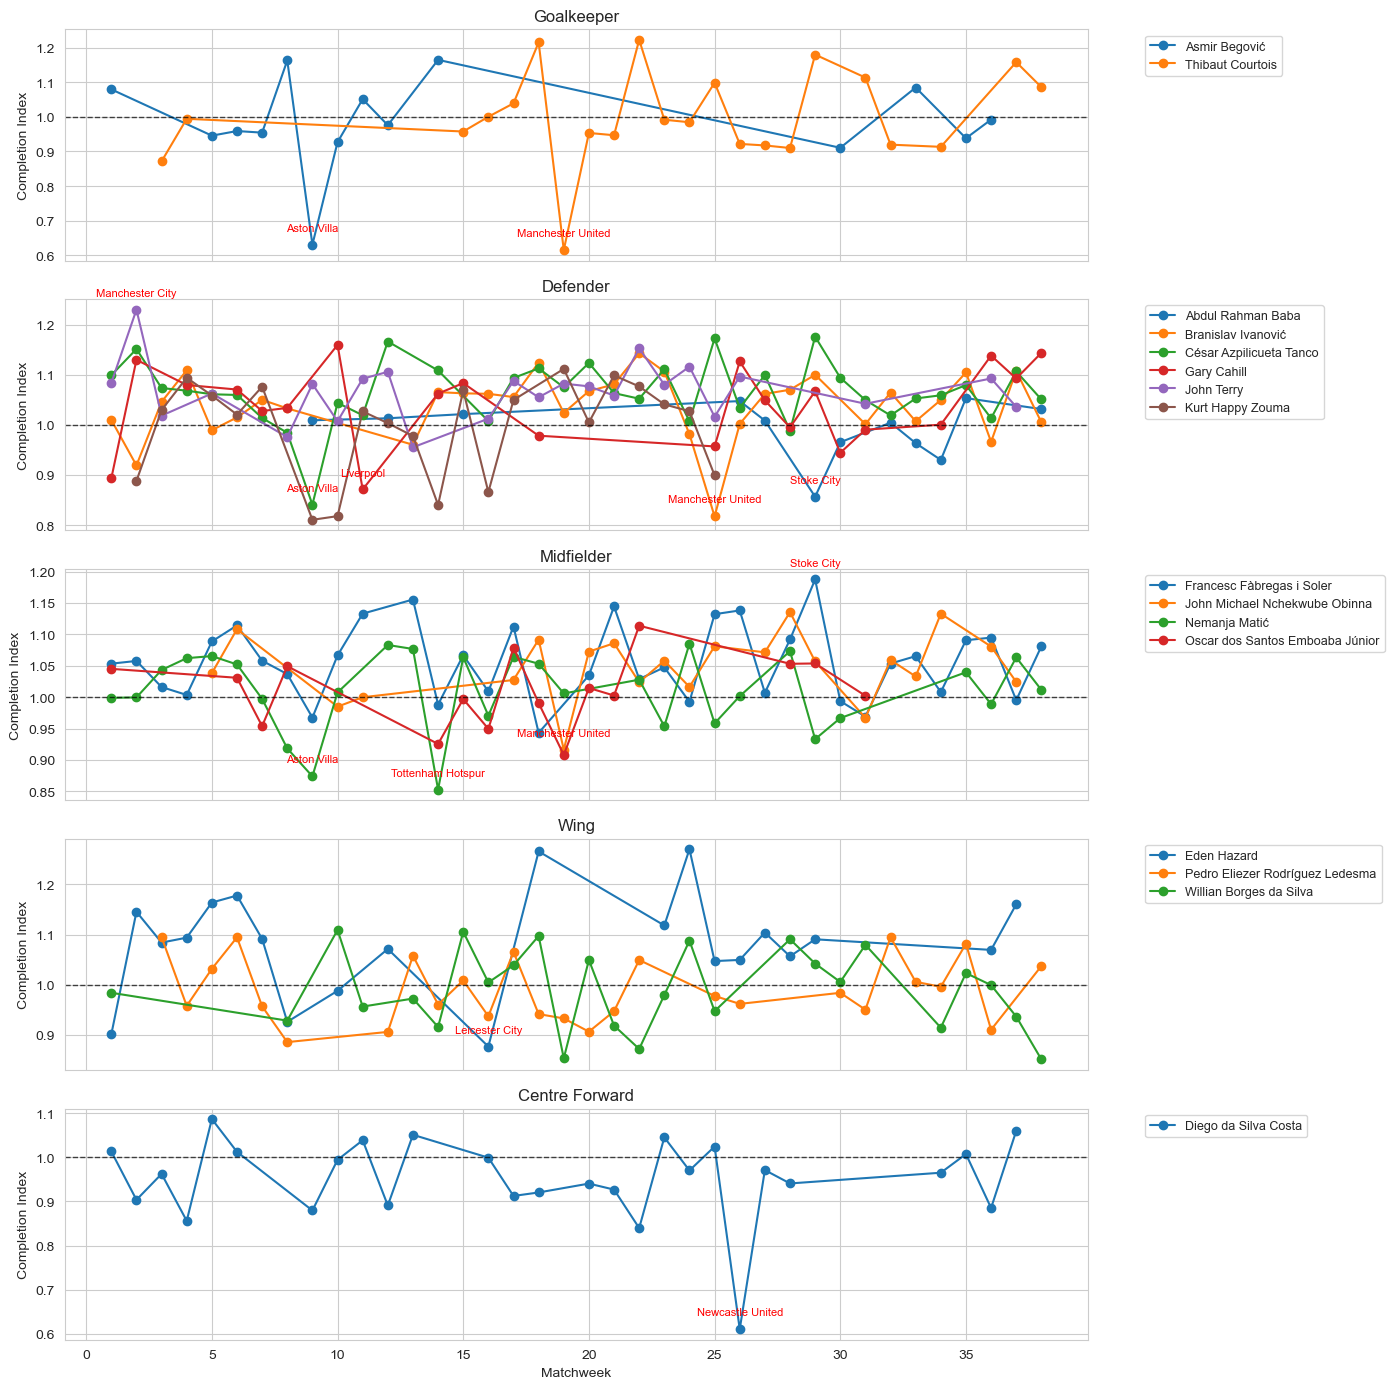

In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Parameters
# --------------------------------------------------
min_passes_per_game = 10  # ignore players with very few passes in a game
min_games_played = 10      # ignore players with fewer than this many games in that position
outlier_std = 2            # how many std deviations away counts as an outlier

# --------------------------------------------------
# Compute opponent dynamically
# --------------------------------------------------
chelsea_df = chelsea_df.copy()
chelsea_df["opponent_team"] = chelsea_df.apply(
    lambda row: row["away_team"] if row["home_team"] == "Chelsea" else row["home_team"],
    axis=1
)

# --------------------------------------------------
# Compute player-game level stats
# --------------------------------------------------
player_game_stats = (
    chelsea_df.groupby(["match_id", "match_week", "player"])
    .agg(
        total_passes=("Outcome", "count"),
        completed_passes=("Outcome", "sum"),
        total_xP=("xP", "sum"),
        position=("position", "first"),
        opponent=("opponent_team", "first")
    )
    .reset_index()
)

# Only keep matches with enough passes
player_game_stats = player_game_stats[player_game_stats["total_passes"] >= min_passes_per_game]

# Compute completion index
player_game_stats["actual_completion_rate"] = player_game_stats["completed_passes"] / player_game_stats["total_passes"]
player_game_stats["expected_completion_rate"] = player_game_stats["total_xP"] / player_game_stats["total_passes"]
player_game_stats["completion_index"] = player_game_stats["actual_completion_rate"] / player_game_stats["expected_completion_rate"]

# --------------------------------------------------
# Map to generic positions
# --------------------------------------------------
def categorize_position(pos):
    pos = str(pos).lower()
    if "goalkeeper" in pos:
        return "Goalkeeper"
    elif "back" in pos:
        return "Defender"
    elif "wing" in pos:
        return "Wing"
    elif "forward" in pos or "striker" in pos or "centre forward" in pos:
        return "Centre Forward"
    elif "midfield" in pos or "attacking" in pos or "defensive" in pos:
        return "Midfielder"
    else:
        return "Other"

player_game_stats["generic_position"] = player_game_stats["position"].apply(categorize_position)

# --------------------------------------------------
# Remove players who didn't play enough games **per position**
# --------------------------------------------------
games_per_player_gpos = (
    player_game_stats.groupby(["player", "generic_position"])["match_id"]
    .nunique()
)
valid_players_gpos = games_per_player_gpos[games_per_player_gpos >= min_games_played].reset_index()[["player", "generic_position"]]

player_game_stats = player_game_stats.merge(valid_players_gpos, on=["player", "generic_position"], how="inner")

# --------------------------------------------------
# Plot: one subplot per generic position with outliers annotated
# --------------------------------------------------
sns.set_style("whitegrid")
generic_positions = ["Goalkeeper", "Defender", "Midfielder", "Wing", "Centre Forward"]
fig, axes = plt.subplots(len(generic_positions), 1, figsize=(14, 14), sharex=True)

for i, gpos in enumerate(generic_positions):
    ax = axes[i]
    subset = player_game_stats[player_game_stats["generic_position"] == gpos]
    
    for player, pdata in subset.groupby("player"):
        pdata_sorted = pdata.sort_values("match_week")
        ax.plot(
            pdata_sorted["match_week"],
            pdata_sorted["completion_index"],
            marker="o",
            label=player
        )
        
        # Annotate outliers
        mean_ci = pdata_sorted["completion_index"].mean()
        std_ci = pdata_sorted["completion_index"].std()
        outliers = pdata_sorted[
            (pdata_sorted["completion_index"] > mean_ci + outlier_std * std_ci) |
            (pdata_sorted["completion_index"] < mean_ci - outlier_std * std_ci)
        ]
        for _, row in outliers.iterrows():
            ax.annotate(
                row["opponent"],
                (row["match_week"], row["completion_index"]),
                textcoords="offset points",
                xytext=(0,10),
                ha="center",
                fontsize=8,
                color="red"
            )
    
    ax.axhline(1, color="black", linestyle="--", linewidth=1, alpha=0.7)  # expected baseline
    ax.set_ylabel("Completion Index")
    ax.set_title(gpos)
    if i == len(generic_positions) - 1:
        ax.set_xlabel("Matchweek")
    ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=9)

plt.tight_layout()
plt.show()

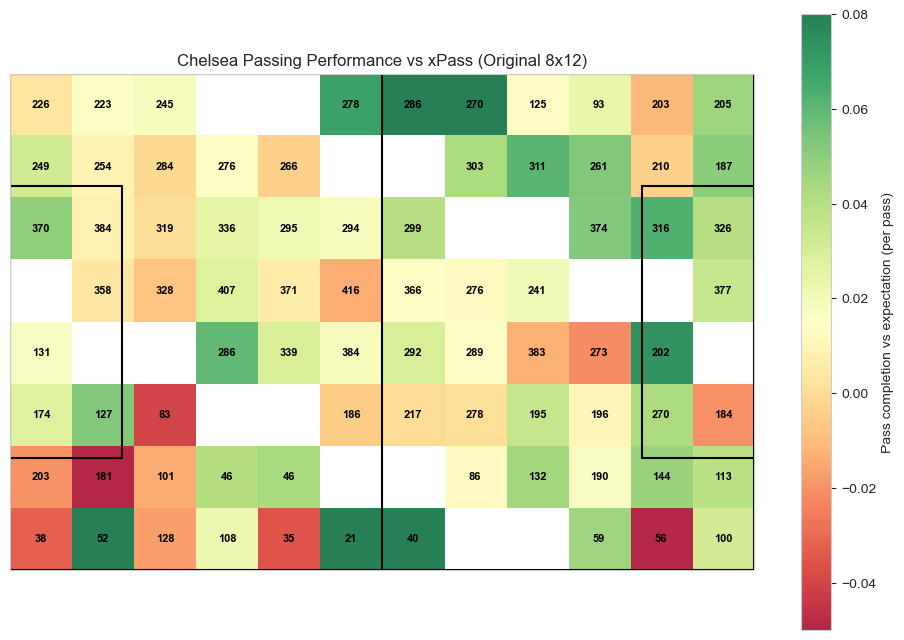

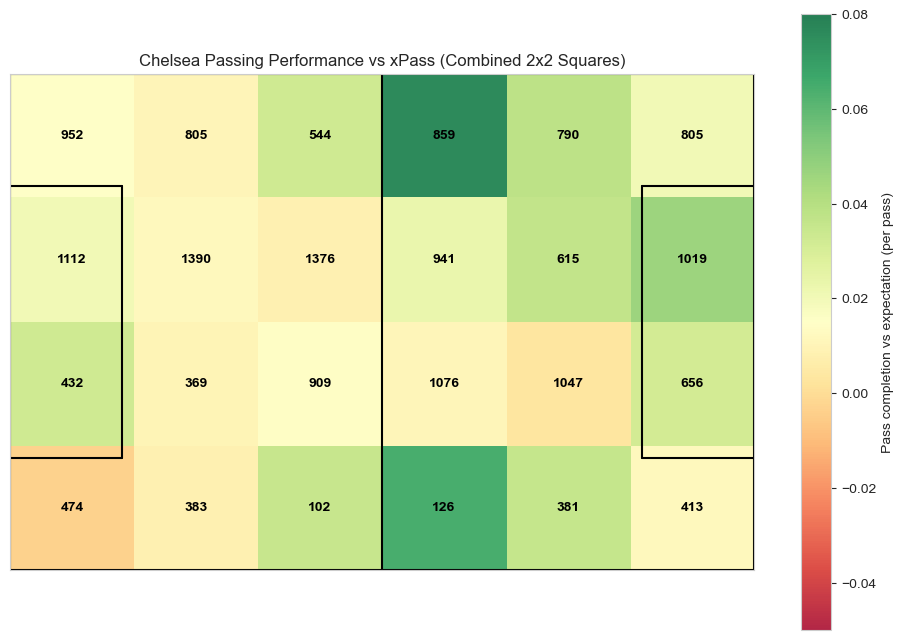

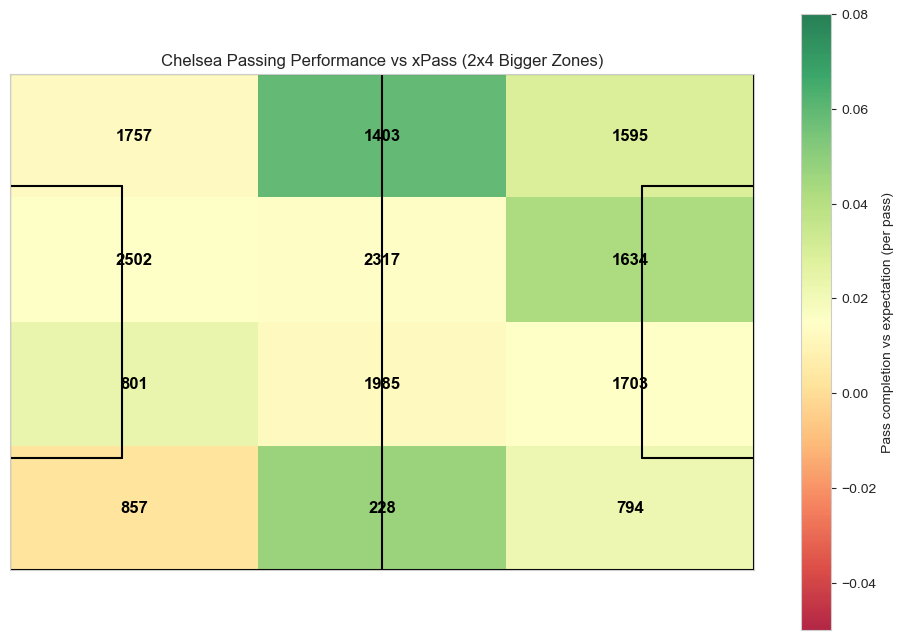

In [167]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Filter Chelsea passes
# --------------------------------------------------
chelsea_df = pl_df[pl_df["team"] == "Chelsea"].copy()

# --------------------------------------------------
# Aggregate performance by start square
# --------------------------------------------------
zone_analysis = (
    chelsea_df
    .groupby("start_square")
    .agg(
        passes=("Outcome", "count"),
        completed=("Outcome", "sum"),
        expected=("xP_calibrated", "sum")
    )
    .reset_index()
)

zone_analysis["difference"] = zone_analysis["completed"] - zone_analysis["expected"]
zone_analysis["difference_per_pass"] = zone_analysis["difference"] / zone_analysis["passes"]

# --------------------------------------------------
# Convert to 8x12 grid
# --------------------------------------------------
rows, cols = 8, 12
zone_grid = np.full((rows, cols), np.nan)
passes_grid = np.full((rows, cols), np.nan)

for _, row in zone_analysis.iterrows():
    try:
        square = int(row["start_square"]) - 1
        r = square // cols
        c = square % cols
        if r < 0 or r >= rows or c < 0 or c >= cols:
            continue
        zone_grid[r, c] = row["difference_per_pass"]
        passes_grid[r, c] = row["passes"]
    except (ValueError, TypeError):
        continue

# --------------------------------------------------
# Set colour scale for all plots
# --------------------------------------------------
vmin = -0.05
vmax = 0.08
    
# --------------------------------------------------
# Function to plot a grid
# --------------------------------------------------
def plot_pitch_grid(grid, passes, title, n_rows, n_cols, fontsize=10):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Pitch outline (StatsBomb 120x80)
    ax.plot([0,120,120,0,0], [0,0,80,80,0], color="black")
    ax.plot([60,60], [0,80], color="black")
    
    # Penalty areas
    ax.plot([102,120], [18,18], color="black")
    ax.plot([102,102], [18,62], color="black")
    ax.plot([102,120], [62,62], color="black")
    ax.plot([0,18], [18,18], color="black")
    ax.plot([18,18], [18,62], color="black")
    ax.plot([0,18], [62,62], color="black")
    
    # Heatmap
    im = ax.imshow(
        grid,
        extent=[0,120,0,80],
        origin="lower",
        cmap="RdYlGn",
        vmin=vmin,
        vmax=vmax,
        alpha=0.85
    )
    
    # Add number of passes
    for r in range(n_rows):
        for c in range(n_cols):
            if not np.isnan(passes[r, c]):
                x = (c + 0.5) * (120 / n_cols)
                y = (r + 0.5) * (80 / n_rows)
                ax.text(x, y, int(passes[r, c]), color="black",
                        ha="center", va="center", fontsize=fontsize, fontweight="bold")
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Pass completion vs expectation (per pass)")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    plt.show()

# --------------------------------------------------
# Plot 1: Original 8x12 grid
# --------------------------------------------------
plot_pitch_grid(zone_grid, passes_grid, "Chelsea Passing Performance vs xPass (Original 8x12)", rows, cols, fontsize=8)

# --------------------------------------------------
# Plot 2: Combined 2x2 squares
# --------------------------------------------------
big_rows, big_cols = rows // 2, cols // 2
big_zone_grid = np.full((big_rows, big_cols), np.nan)
big_passes_grid = np.full((big_rows, big_cols), np.nan)

for r in range(big_rows):
    for c in range(big_cols):
        small_r = slice(r*2, r*2+2)
        small_c = slice(c*2, c*2+2)
        small_zone = zone_grid[small_r, small_c]
        small_passes = passes_grid[small_r, small_c]

        big_zone_grid[r, c] = np.nanmean(small_zone) if not np.isnan(small_zone).all() else np.nan
        big_passes_grid[r, c] = np.nansum(small_passes)

plot_pitch_grid(big_zone_grid, big_passes_grid, "Chelsea Passing Performance vs xPass (Combined 2x2 Squares)", big_rows, big_cols, fontsize=10)

# --------------------------------------------------
# Plot 3: Combined 2x4 bigger zones (2 rows × 4 cols)
# --------------------------------------------------
big_rows, big_cols = rows // 2, cols // 4
big_zone_grid_2x4 = np.full((big_rows, big_cols), np.nan)
big_passes_grid_2x4 = np.full((big_rows, big_cols), np.nan)

for r in range(big_rows):
    for c in range(big_cols):
        small_r = slice(r*2, r*2+2)
        small_c = slice(c*4, c*4+4)
        small_zone = zone_grid[small_r, small_c]
        small_passes = passes_grid[small_r, small_c]

        big_zone_grid_2x4[r, c] = np.nanmean(small_zone) if not np.isnan(small_zone).all() else np.nan
        big_passes_grid_2x4[r, c] = np.nansum(small_passes)

plot_pitch_grid(big_zone_grid_2x4, big_passes_grid_2x4, "Chelsea Passing Performance vs xPass (2x4 Bigger Zones)", big_rows, big_cols, fontsize=12)